# **Multi-Class CNN with Severe Class Imbalance from Combined Datasets - Computer Vision (Classification)**

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    </header>
    <section>
        <p><strong>Machine Learning Engineer (aspiring):</strong> Ian H. Ryan</p>
        <p><strong>Project Length:</strong> March 2025 - April 2025</p>
        <p><strong>Description:</strong> A Complete overhaul of my <strong><a href="https://github.com/ianhenryryan/capstone" target="_blank">Capstone Project</a></strong>. For my capstone, I took on the challenge of building a <strong>multi-class Convolutional Neural Network</strong> from scratch using <strong>PyTorch</strong>, with the explicit constraint of <em>not using pre-trained models</em> (such as ResNet, MobileNet, etc). The model was designed to handle <strong>severe class imbalance</strong>, mirroring real-world challenges often seen in production data. Instead of using balanced or curated datasets, I intentionally created an extreme case of class imbalance by merging two different datasets. One of the 18 classes makes up 50% of the images, while the remaining 17 classes split the other half.

Since graduating, I’ve been refining this project and correcting mistakes that were present in the original capstone version. One major issue I uncovered was that I had incorrectly combined the datasets, which resulted in misclassified images and even some completely empty classes — <strong>making all the original training results invalid</strong>. I committed to debugging everything: redundant code, mismatched variable names, inconsistent transforms, and broken visualizations. Once the pipeline was stable and fully functional, I moved on to implementing upgrades across the board — from dataset engineering and augmentation to better loss strategies and metrics. It became a personal challenge — one I used to reinforce core deep learning concepts under tougher, more realistic conditions. 

It’s been a fun dissection that’s helped me grow—improving my skills, decision making, and overall approach to building machine learning pipelines, while continuing my journey of finding employment after graduating in December 2024.

<strong>for in-depth analysis of Capstone VS this version, check out my blog post @ https://ianhryan.com/blog.html</strong></p>
    </section>
<hr>
  <p>
    <strong>The combined dataset includes:</strong><br>
    - <strong><a href="https://universe.roboflow.com/pascal-to-yolo-8yygq/inria-person-detection-dataset" target="_blank">INRIA Person Detection Dataset</a></strong> (Roboflow Universe) by user <strong>Pascal to Yolo</strong>: 902 images of class <code>person</code>, manually split 70/20/10 for train/val/test.<br>
    - <strong><a href="https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/data" target="_blank">Animal Image Dataset</a></strong> (Kaggle) by user <strong>iamsouravbanerjee</strong>: 17 cherry-picked animal classes from their 90 total, totaling 902 images, also split 70/20/10.
  </p>

  <p>
    This resulted in a <strong>long-tail distribution</strong> — where one class dominates, and the rest are minority classes with as few as ~37 images each in training. Notably difficult classes include <strong>badger</strong>, <strong>possum</strong>, <strong>porcupine</strong>, and visually similar primates like <strong>chimpanzee</strong>, <strong>gorilla</strong>, and <strong>orangutan</strong>.
  </p>

  <hr>

  <p>
    <strong>This version of the notebook reflects a full transformation from the original capstone project.</strong><br>
    The primary goals were:
    <ul>
      <li>Improve <strong>training stability</strong> under mixed-precision (AMP)</li>
      <li>Ensure <strong>reproducibility</strong> through structured config and deterministic data processing</li>
      <li>Optimize for <strong>generalization</strong> on a limited hardware setup (NVIDIA 3060 mobile GPU)</li>
    </ul>
  </p>

  <h3>Highlights</h3>
  <ul>
    <li>Custom-built CNN architecture (no transfer learning)</li>
    <li><strong>MixUp</strong> augmentation with soft-label-compatible <strong>Focal Loss</strong></li>
    <li><strong>WeightedRandomSampler</strong> to balance class exposure across epochs</li>
    <li><strong>Per-class threshold tuning</strong> based on softmax probabilities</li>
    <li>AMP (mixed precision) training loop with <strong>early stopping</strong> and best model saving</li>
    <li><strong>Lightweight, memory-aware training</strong> compatible with constrained local GPUs</li>
  </ul>
</body>
</html>

### ✅ Key Improvements

- **Fixed dataset corruption bug** due to class label offset after dataset merging  
- **MixUp augmentation + SoftTarget FocalLoss** with per-class weighting  
- **WeightedRandomSampler** to ensure fair sampling across all classes  
- **Dynamic architecture upgrades**:  
  - ReLU → GELU (Conv layers), ReLU → LeakyReLU (FC layers)  
  - BatchNorm1d reordered to follow activation (pretrained model pattern)  
  - Added Dropout and bottleneck layers for regularization  
- **AMP (mixed precision)** with custom `ToFloat32()` patch for stable training  
- **Optimizer improvement:** no weight decay on bias/BatchNorm  
- **Scheduler tuning:** settled on `ReduceLROnPlateau(mode='max')` after testing alternatives  
- **Early stopping** with best F1 + val accuracy model checkpointing  
- **CUDA memory management**, soft-label handling, and cleaner loader logic  

---

### 🧰 Utility Enhancements

- `class_names.json` and `dataset_stats.json` saved for reusability  
- Modular utility functions (verify structure, convert formats, cleanup, etc.)  
- Visualizations for dataset class balance and training metrics  

#### ✍️ Run Notes / Changelog Draft

- [ ] Updated `MixUp alpha` from 0.4 to 0.2
- [ ] Changed `weight_decay` from 5e-5 to 1e-5
- [ ] Switched scheduler from
- [ ] Restored label smoothing to 0.1
- [ ] CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6) -> CosineAnnealingWarmRestarts(optimizer, T_0=6, T_mult=1, eta_min=1e-6)

# Index

## **Table of Contents**
- [Libraries & Imports](#libraries--imports)
  - [Libraries](#libraries)
  - [Imports](#imports)
- [Check GPU Availability for CUDA](#check-gpu-availability-for-cuda)
- [CUDA allocation limiting ~64mb](#cuda-allocation-limiting-64mb)
- [Seed](#seed)
- [Utility Functions & Archived Debugging (Not Used in This Notebook)](#utility-functions--archived-debugging-not-used-in-this-notebook)
- [Download & Load Datasets](#download--load-datasets)
  - [First Dataset Resource](#first-dataset-resource)
  - [Second Dataset Resource](#second-dataset-resource)
- [Path Datasets](#path-datasets)
  - [First Dataset](#first-dataset)
  - [Second Dataset](#second-dataset)
- [Merge & Prepare Datasets](#merge--prepare-datasets)
  - [Build Combined Dataset (Class Merge + Folder Setup)](#build-combined-dataset-class-merge--folder-setup)
  - [Combine The Datasets](#combine-the-datasets)
  - [Save Combo Set](#save-combo-set)
  - [Delete Raw Datasets to Reclaim CUDA Memory](#delete-raw-datasets-to-reclaim-cuda-memory)
- [Resume From Checkpoint: Load Combined Class Info](#resume-from-checkpoint-load-combined-class-info)
- [Global Config: Paths, Splits, and Dataset Setup](#global-config-paths-splits-and-dataset-setup)
  - [Check Combined Folder Structure (Train/Valid/Test)](#check-combined-folder-structure-trainvalidtest)
  - [Stats & Class Distribution](#stats--class-distribution)
- [Mean & Std](#mean--std)
- [Classification Or Object Detection Model?](#classification-or-object-detection-model)
  - [Classification Task (e.g., Image Classification)](#classification-task-eg-image-classification)
  - [Regression Task (e.g., Object Detection or Localization)](#regression-task-eg-object-detection-or-localization)
- [MixUp Dataset Wrapper](#mixup-dataset-wrapper)
- [Transforms & Loaders](#transforms--loaders)
- [CNN Model](#cnn-model)
  - [Define Class Weights](#define-class-weights)
    - [Log-scaled Inverse Frequency Logic - Class Weighting Strategy](#log-scaled-inverse-frequency-logic---class-weighting-strategy)
    - [Visualization Bar Chart - Weights Assigned To Each Class](#visualization-bar-chart---weights-assigned-to-each-class)
  - [Define Lightweight Layer IF cublasLtMatmulAlgoGetHeuristic](#define-lightweight-layer-if-cublasltmatmulalgogetheuristic)
  - [Define CNN Model Architecture](#define-cnn-model-architecture)
  - [Weights & Biases](#weights--biases)
    - [Weight Initialization](#weight-initialization)
  - [Hyperparameters](#hyperparameters)
    - [Epochs, Learning Rate, Accumulation Steps](#epochs-learning-rate-accumulation-steps)
  - [Loss Function](#loss-function)
    - [Custom FocalLoss](#custom-focalloss)
  - [Mixed Precision Training - Autocast & GradScaler](#mixed-precision-training---autocast--gradscaler)
    - [Optimizer & Learning Rate Scheduler](#optimizer--learning-rate-scheduler)
  - [Profile Memory Usage](#profile-memory-usage)
  - [Training CNN Model](#training-cnn-model)
- [Save Metadata Alongside Best Weights](#save-metadata-alongside-best-weights)
- [Save Summary & Classification Report](#save-summary--classification-report)
- [Auto-Create Config](#auto-create-config)
- [Log Training History](#log-training-history)
- [Create ChangeLog](#create-changelog)
- [Create ChangeLog & Config](#create-changelog--config)
- [Save Model Weights or Save Model of Training](#save-model-weights-or-save-model-of-training)
- [Test Accuracy of CNN Training](#test-accuracy-of-cnn-training)
- [Visualizations](#visualizations)
  - [Metrics](#metrics)
    - [Summary](#summary)
    - [Evaluate Per Class Metrics](#evaluate-per-class-metrics)
    - [Model Performance](#model-performance)
    - [Check class representation in the dataset](#check-class-representation-in-the-dataset)
  - [Visuals](#visuals)
    - [Learning Rate Visual](#learning-rate-visual)
    - [F1-Score over Epochs Validation](#f1-score-over-epochs-validation)
    - [Training/Validation Curves](#trainingvalidation-curves)
    - [Training & Validation Loss Plots](#training--validation-loss-plots)
    - [Confusion Matrices](#confusion-matrices)
    - [Feature Maps](#feature-maps)
    - [Kernel/Visualizations](#kernelvisualizations)
    - [Gradient Visualization](#gradient-visualization)
    - [CAM/Grad-CAM](#camgrad-cam)
    - [Explainability Tools](#explainability-tools)
    - [Side-by-Side: Original, IG, and Grad-CAM](#side-by-side-original-ig-and-grad-cam)
    - [Compare with Target Class (Grad-CAM)](#compare-with-target-class-grad-cam)
- [Acknowledgements](#acknowledgements)
- [Environment](#environment)
- [Recommended Resources](#recommended-resources)
- [Permission](#permission)

# **Libraries & Imports** <a id="libim"></a>

## Libraries<a id="libraries"></a>

`!pip freeze > requirements.txt` done in a code cell will save all the versions of the pip installs for you. Excellent for documentation and recreatability.

In [1]:
%%capture

# instal the libraries
!pip install -U -q -r requirements.txt

Restart Kernel by running following cell.

In [2]:
from IPython.display import HTML, display
def restart_kernel_and_run_all_cells():
    display(HTML(
        '''
            <script>
                code_show = false;
                var cell_idx = Jupyter.notebook.get_cell_elements().index(cell_element);
                cell_idx++;
                function restart(){
                    IPython.notebook.kernel.restart();
                    IPython.notebook.execute_cells([cell_idx])
                }
                restart()
            </script>
        '''
    ))
#print("Before you continue, wait until the kernel is ready again.")
restart_kernel_and_run_all_cells()

## Imports <a id="imports"></a>

In [3]:
%matplotlib inline

# Python
import os, shutil, time, gc, random, json, math
from collections import Counter
# Image handling
from PIL import Image
# Math & Arrays
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
# PyTorch & TorchVision
import torch
import torch.nn.functional as F
from torch import nn
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, ConcatDataset, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torch.optim as optim
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau, OneCycleLR, CosineAnnealingWarmRestarts
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
# Visualization tools
from torchviz import make_dot
# Model explainability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torchvision.transforms.functional import normalize
# Model summary
from torchsummary import summary
# Sklearn utilities
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
# Progress bar
from tqdm import tqdm
# Date & Time
from datetime import datetime
# Captum
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

## Check GPU Availability for CUDA? <a id="checkgpucuda"></a>

In [4]:
print("CUDA available:", torch.cuda.is_available())
print("# of GPUs Available:", torch.cuda.device_count())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

CUDA available: True
# of GPUs Available: 1


'cuda'

## CUDA allocation limiting ~64mb
limit cuda memory if errors persist

In [5]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64"

## Seed

In [6]:
def set_seed(seed=42):
    random.seed(seed)              # Python’s built-in random module
    np.random.seed(seed)           # NumPy random seed
    torch.manual_seed(seed)        # PyTorch seed for CPU
    torch.cuda.manual_seed_all(seed)  # PyTorch seed for all CUDA GPUs
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [7]:
set_seed()
seed = 42

## Utility Functions & Archived Debugging (Not Used in This Notebook)
These functions are not directly used in this project but may be useful for future datasets. For example, `convert_images_to_format()` can batch convert image formats across a directory (e.g., PNG → JPG

#### Convert Image Format
Normalizes all file extensions
Converts any supported image format to your desired format
Works recursively over an entire dataset directory
Automatically skips already converted files
Uses PIL for safe, universal compatibility

In [ ]:
def convert_images_to_format(base_dir, target_format='jpg', delete_original=False):
    """
    Converts all image files in the given directory (recursively) to a specified format.
    
    Args:
        base_dir (str): Base folder path to search for image files.
        target_format (str): Desired file format (e.g., 'jpg', 'png').
        delete_original (bool): Whether to delete the original files after conversion.
    """
    supported_formats = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif')
    target_format = target_format.lower()

    if target_format not in ['jpg', 'jpeg', 'png', 'bmp', 'tif', 'tiff']:
        raise ValueError(f"Unsupported target format: {target_format}")

    print(f"Converting all images in {base_dir} to .{target_format}...\n")

    for root, _, files in os.walk(base_dir):
        
        for file in files:
            file_path = os.path.join(root, file)

            # Normalize file extensions to lowercase
            if not file.islower():
                lower_file = file.lower()
                lower_path = os.path.join(root, lower_file)
                os.rename(file_path, lower_path)
                file_path = lower_path
                file = lower_file

            if file.endswith(supported_formats):
                try:
                    with Image.open(file_path) as img:
                        base_name = os.path.splitext(file)[0]
                        new_file_path = os.path.join(root, base_name + f".{target_format}")

                        if not os.path.exists(new_file_path):
                            img.convert('RGB').save(new_file_path, target_format.upper())
                            print(f"✔ Converted: {file_path} → {new_file_path}")

                        if delete_original and file_path != new_file_path:
                            os.remove(file_path)

                except Exception as e:
                    print(f"⚠️ Error converting {file_path}: {e}")

    print(f"\n✅ Conversion to .{target_format} complete.")

In [ ]:
# Convert everything in the comboset to .png and keep originals
# convert_images_to_format('data/comboset', target_format='png', delete_original=False)
# Convert everything under comboset to .jpg (keep originals)
# convert_images_to_format("data/comboset", target_format="jpg", delete_original=False)
# Convert to .jpg and delete original formats
# convert_images_to_format('data/comboset', target_format='jpg', delete_original=True)

#### Recursive remove .ipynb_checkpoints folders at directed folder.
Yes, Unfortunately this notebook problem keeps appearing so thus recursive. call function for each dataset upload path. this will fix a bug in AWS SageMaker that keeps recognizing .ipynb_checkpoints in folders it is not in. Call when needed for .ipynb_checkpoints error

In [ ]:
def clean_checkpoints(base_path):
    """
    Recursively remove all .ipynb_checkpoints folders in a directory.
    """
    for root, dirs, _ in os.walk(base_path):
        for folder in dirs:
            if folder == '.ipynb_checkpoints':
                checkpoint_path = os.path.join(root, folder)
                shutil.rmtree(checkpoint_path)
                print(f"Removed: {checkpoint_path}")

#### Normalize File Extensions <a id="normalize-file-extensions"></a>

In [ ]:
# TESTING THIS ONE. MIGHT NEED TO USE THIS OR THE OG ONE ABOVE TRYING RN
# def normalize_file_extensions(folder):
#    for root, _, files in os.walk(folder):
#        for file in files:
#            if file.endswith(('.JPG', '.JPEG', '.TIF', '.TIFF')):
#                os.rename(
#                    os.path.join(root, file),
#                    os.path.join(root, file.lower())
#                )
#
# Normalize valid path
# normalize_file_extensions(combo_path)
# normalize_file_extensions(val_path)
# normalize_file_extensions(train_path)

#### Normalize Filenames 
If the issue is due to case sensitivity or special characters, normalize the filenames with this function:

In [ ]:
def normalize_filenames(directory):
    """
    Normalize filenames in the given directory and its subdirectories.
    Ensures all filenames are in lowercase and replace spaces with underscores.
    Args:
        directory (str): Path to the directory to normalize filenames.
    """
    for root, _, files in os.walk(directory):
        for file in files:
            old_path = os.path.join(root, file)
            # Normalize filename
            normalized_name = file.lower().replace(" ", "_")
            new_path = os.path.join(root, normalized_name)
            # Rename file if necessary
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f"Renamed: {old_path} -> {new_path}")

#### Show Image
useful to see the imported data quickly and randomly.

In [ ]:
# not required but useful to see the imported data quickly and randomly.
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(img.permute(1,2,0).numpy())
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

# Peek at some of the dataset images!

test_dataset = ImageFolder(test_path, transform=transforms.ToTensor())
test_sample = DataLoader(test_dataset, batch_size=2*8, shuffle=True)

# You can run this cell over and over seeing different images.
for data, label in test_sample:
    show_images(data, 2, 2);
    break

#### .ipynb_checkpoints Debugging

In [ ]:
# CHECK IF .ipynb_checkpoints EXISTS
# Check if .ipynb_checkpoints exists
# checkpoint_path = os.path.join(val_path, '.ipynb_checkpoints')
# if os.path.exists(checkpoint_path):
#    print(f".ipynb_checkpoints exists at: {checkpoint_path}")
# else:
#    print(".ipynb_checkpoints does not exist.")

In [ ]:
# This kills the checkpoint error. Run if getting it.
# Path dir path

# decimate ipynb_checkpoints folder
checkpoint_path = os.path.join(val_path, '.ipynb_checkpoints')
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
    print(f"decimated: {checkpoint_path}")
else:
    print(f".ipynb_checkpoints folder found at {checkpoint_path}")

In [ ]:
print(f"Contents of valid directory after cleanup: {os.listdir(val_path)}")

#### Inspect test path and confirm it has class folders and these folders have valid files.

In [ ]:
# Verify test_path exists
print(f"Test path exists: {os.path.exists(test_path)}")
print(f"Test path: {test_path}")

In [ ]:
#Valid path?

val_path = os.path.join(in_path, 'valid')
person_path = os.path.join(val_path, 'person')

# Check if the directory exists
print(f"Does 'person' class directory exist? {os.path.exists(person_path)}")

# List files in the 'person' directory
if os.path.exists(person_path):
    print(f"Files in 'person' directory: {os.listdir(person_path)}")
else:
    print("'person' class directory not found.")


#### OPTIONAL: Check that dataset loaded properly by printing a few images.

In [ ]:
# List classes and their files in test_path
if os.path.exists(test_path):
    classes = os.listdir(test_path)
    print(f"Classes in test_path: {classes}")

    for class_name in classes:
        class_dir = os.path.join(test_path, class_name)
        if os.path.isdir(class_dir):
            print(f"Files in class '{class_name}': {os.listdir(class_dir)}")
        else:
            print(f"{class_name} is not a directory!")

### Optional utility: Get Combined Classes Function

In [ ]:
# Optional utility: Only needed if class_names.json is missing or needs rebuilding

def get_combined_classes(directory):
    """
    Generate a list of class names based on folder names in the directory.
    Args:
        directory (str): Path to the dataset directory (e.g., train, valid, or test folder).
    Returns:
        list: Sorted list of class names.
    """
    if os.path.exists(directory):
        return sorted(next(os.walk(directory))[1])  # Get folder names in the directory
    else:
        raise FileNotFoundError(f"Directory {directory} does not exist.")

# combined_classes = get_combined_classes(train_path)  # Assuming train_path contains the class folders
# print(combined_classes)

### Verify Images Function
Debug the Dataset
Verify the dataset to ensure all images are valid and consistent.

Check for Corrupted Images
Use the following script to identify and optionally remove corrupted images:

In [ ]:
def verify_images(directory):
    corrupted_count = 0
    total_count = 0
    
    for root, _, files in os.walk(directory):
        for file in files:
            filepath = os.path.join(root, file)
            total_count += 1
            try:
                img = Image.open(filepath)
                img.verify()  # Verify image integrity
            except Exception as e:
                corrupted_count += 1
                print(f"Corrupted file: {filepath}, {e}")
                if remove_corrupted:
                    os.remove(filepath)  # Remove corrupted files (optional)

    print(f"\nChecked {total_count} files.")
    print(f"Corrupted images found: {corrupted_count}")
    if corrupted_count == 0:
        print("✅ All images are valid!")

# Verify training and validation datasets
# verify_images('data/comboset/train')
# verify_images('data/comboset/valid')
# verify_images(train_path)
# verify_images(val_path)
# verify_images(test_path)

In [ ]:
# b4 training or after copying data
# verify_images("data/comboset", remove_corrupted=True)
# scan for issues
# verify_images("data/comboset", remove_corrupted=False)

### Predict Image Utility Function

In [ ]:
# --- Inference Utility Function ---
def predict_image(image_path, model, transform, class_names):
    """
    Predict the class of a single image using the trained model.
    """
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        pred = output.argmax(dim=1).item()

    return class_names[pred]


# Download & Load Datasets <a id="download-datasets"></a>
Datasets for CNN Model Training for human detection that has the following classes:
- person (from INRIA-pdd)    902 human images (train - 70%, test - 10%, val - 20%)
- animals (17 total classes) [from animal]     902 non-human images (train - 70%, test - 10%, val - 20%)

### First Dataset Resource <a id="first-dataset-resource"></a>

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>

<p>
    Access the dataset here: 
    <a href="https://universe.roboflow.com/pascal-to-yolo-8yygq/inria-person-detection-dataset" target="_blank">
        INRIA Person Detection Dataset
    </a>
</p>

<p>
    <strong>Credit:</strong> Dataset created by <em>[Pascal to Yolo]</em> and hosted on 
    <a href="https://universe.roboflow.com/" target="_blank">Roboflow Universe</a>.
</p>

</body>
</html>

### Second Dataset Resource <a id="second-dataset-resource"></a>

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <style>
        body {
            font-family: Arial, sans-serif;
            line-height: 1.6;
        }
        h2 {
            color: #333;
        }
        a {
            color: #0066cc;
            text-decoration: none;
        }
        a:hover {
            text-decoration: underline;
        }
    </style>
</head>
<body>


<p>
    Access the dataset here: 
    <a href="https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/data" target="_blank">
        Animal Image Dataset (90 Different Animals)
    </a>
</p>

<p>
    <strong>Credit:</strong> Dataset created by <em>Sourav Banerjee</em> and hosted on 
    <a href="https://www.kaggle.com/" target="_blank">Kaggle</a>.
</p>

</body>
</html>

# Path Datasets <a id="path-datasets"></a>

#### _First Dataset_ <a id="first-dataset"></a>

In [ ]:
in_path = 'data/INRIA-pdd'
train_path = os.path.join(in_path, 'train')
val_path = os.path.join(in_path, 'valid')
test_path = os.path.join(in_path, 'test')

#### _Second Dataset_ <a id="first-dataset"></a>

In [ ]:
an_path = 'data/animal'
train_path = os.path.join(an_path, 'train')
val_path = os.path.join(an_path, 'valid')
test_path = os.path.join(an_path, 'test')

# Merge & Prepare Datasets

## Build Combined Dataset (Class Merge + Folder Setup)

In [ ]:
def build_combined_datasets(inria_path, animal_path):
    """
    Loads INRIA and Animal datasets (train, valid, test), offsets labels for Animal dataset,
    and combines them using ConcatDataset.
    Args:
        inria_path (str): Root path of the INRIA dataset (should contain train/valid/test subfolders)
        animal_path (str): Root path of the Animal dataset (should contain train/valid/test subfolders)
    Returns:
        train_dataset, val_dataset, test_dataset, combined_classes
    """
    # Load INRIA datasets
    in_train = ImageFolder(os.path.join(inria_path, 'train'))
    in_val = ImageFolder(os.path.join(inria_path, 'valid'))
    in_test = ImageFolder(os.path.join(inria_path, 'test'))

    # Load Animal datasets
    an_train = ImageFolder(os.path.join(animal_path, 'train'))
    an_val = ImageFolder(os.path.join(animal_path, 'valid'))
    an_test = ImageFolder(os.path.join(animal_path, 'test'))

    # Get class lists & compute label offset
    in_classes = in_train.classes
    an_classes = an_train.classes
    combined_classes = in_classes + an_classes
    combined_classes = sorted(set(combined_classes))
    
    offset = len(in_classes)

    print(f"INRIA Classes: {in_classes}")
    print(f"Animal Classes: {an_classes}")
    print(f"Offset for Animal Classes: {offset}")
    print(f"Combined Classes: {combined_classes}")

    # Apply label offset to Animal datasets
    def offset_labels(dataset, offset):
        for i in range(len(dataset.samples)):
            path, label = dataset.samples[i]
            dataset.samples[i] = (path, label + offset)
        return dataset

    an_train = offset_labels(an_train, offset)
    # Combine datasets
    train_dataset = ConcatDataset([in_train, an_train])
    val_dataset = ConcatDataset([in_val, an_val])
    test_dataset = ConcatDataset([in_test, an_test])

    # Summary
    print(f"Train size: {len(train_dataset)}")
    print(f"Val size: {len(val_dataset)}")
    print(f"Test size: {len(test_dataset)}")

    an_val = offset_labels(an_val, offset)
    an_test = offset_labels(an_test, offset)

    return train_dataset, val_dataset, test_dataset, combined_classes

In [ ]:
# if not using below section.
train_dataset, val_dataset, test_dataset, combined_classes = build_combined_datasets(in_path, an_path)

## Combine The Datasets <a id="combine-datasets"></a>

In [ ]:
in_train = ImageFolder(os.path.join(in_path, 'train'))
an_train = ImageFolder(os.path.join(an_path, 'train'))

# acquire class names & compute label offset
in_classes = in_train.classes
an_classes = an_train.classes
combined_classes = in_classes + an_classes
offset = len(in_classes)

print(f"Combined Classes: {combined_classes}")
print(f"# of Combined Classes: {len(combined_classes)}")
print(f"Offset for animal classes: {offset}")

# offset labels for animal training set
for i in range(len(an_train.samples)):
    path, label = an_train.samples[i]
    an_train.samples[i] = (path, label + offset)

# Load validation datasets
in_val = ImageFolder(os.path.join(in_path, 'valid'))
an_val = ImageFolder(os.path.join(an_path, 'valid'))

# Offset labels for animal validation set
for i in range(len(an_val.samples)):
    path, label = an_val.samples[i]
    an_val.samples[i] = (path, label + offset)

# Load test datasets
in_test = ImageFolder(os.path.join(in_path, 'test'))
an_test = ImageFolder(os.path.join(an_path, 'test'))

# Offset labels for animal test set
for i in range(len(an_test.samples)):
    path, label = an_test.samples[i]
    an_test.samples[i] = (path, label + offset)

# Merge datasets via ConcatDataset
train_dataset = ConcatDataset([in_train, an_train])
val_dataset = ConcatDataset([in_val, an_val])
test_dataset = ConcatDataset([in_test, an_test])

# dataset stats
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
total_size = train_size + val_size + test_size

# Print summary
print("\ndataset split summary:")
print(f"total images: {total_size}")
print(f"training: {train_size} ({(train_size/total_size)*100:.2f}%)")
print(f"talidation: {val_size} ({(val_size/total_size)*100:.2f}%)")
print(f"testing: {test_size} ({(test_size/total_size)*100:.2f}%)")
print(f"adjusted labels in animal train dataset: {set(label for _, label in an_train.samples)}")

## Save Combo Set <a id="save-combo-set"></a>

In [ ]:
def save_combo_dataset(train_dataset, val_dataset, test_dataset, save_path = 'data/comboset', overwrite=False):
    """
    Save combined train, validation, and test datasets into a unified folder structure.
    Args:
        train_dataset: Combined training dataset (ConcatDataset)
        val_dataset: Combined validation dataset (ConcatDataset)
        test_dataset: Combined test dataset (ConcatDataset)
        combined_classes (list): List of class names in correct order
        save_path (str): Destination path for the combined dataset
        overwrite (bool): If True, overwrite existing files
    """
    # Map the datasets to splits
    splits = {'train': train_dataset, 'valid': val_dataset, 'test': test_dataset}

    # Create the base save directory
    os.makedirs(save_path, exist_ok=True)

    for split_name, dataset in splits.items():
        split_path = os.path.join(save_path, split_name)
        os.makedirs(split_path, exist_ok=True)

        # Extract classes via dataset
        # Handle ConcatDataset or plain Dataset
        if hasattr(dataset, "datasets"):
            combined_classes = dataset.datasets[0].classes + dataset.datasets[1].classes
        else:
            combined_classes = dataset.classes

        # Create folders for each class if they don't already exist
        for class_name in combined_classes:
            class_folder = os.path.join(split_path, class_name)
            os.makedirs(class_folder, exist_ok=True)

        # Handle ConcatDataset or plain Dataset
        if hasattr(dataset, "datasets"):
            datasets = dataset.datasets
        else:
            datasets = [dataset]

        for sub_index, sub_dataset in enumerate(datasets):
            for i, (image_path, label) in enumerate(tqdm(sub_dataset.samples, desc=f"Saving {split_name}")):
                class_name = combined_classes[label]
                class_folder = os.path.join(split_path, class_name)

                # Unique filename using sub-dataset index + original name
                base_name = os.path.basename(image_path)
                unique_name = f"{sub_index}_{i}_{base_name}"
                dest_path = os.path.join(class_folder, unique_name)

                if not os.path.exists(dest_path) or overwrite:
                    shutil.copy(image_path, dest_path)

    print(f"Combined dataset saved: {save_path}")
    
    # Save class names -> JSON
    class_names_path = os.path.join(save_path, 'class_names.json')
    with open(class_names_path, 'w') as f:
        json.dump(combined_classes, f)

    print(f"Class names saved to: {class_names_path}")

    # Save dataset stats -> JSON
    dataset_stats = {
        "class_distribution": {},
        "splits_percentage": {},
        "total_images": 0,
        "offset_applied_to": "animal",
        "offset_value": offset
    }

    total_count = 0

    for split_name in splits:
        split_path = os.path.join(save_path, split_name)
        split_stats = {}
        for class_name in combined_classes:
            class_dir = os.path.join(split_path, class_name)
            num_images = len(os.listdir(class_dir)) if os.path.exists(class_dir) else 0
            split_stats[class_name] = num_images
            total_count += num_images

        dataset_stats["class_distribution"][split_name] = split_stats

    # Compute percentages
    for split_name in splits:
        split_total = sum(dataset_stats["class_distribution"][split_name].values())
        pct = (split_total / total_count) * 100 if total_count else 0
        dataset_stats["splits_percentage"][split_name] = f"{pct:.2f}%"

    dataset_stats["total_images"] = total_count

    # Save to JSON
    stats_path = os.path.join(save_path, "dataset_stats.json")
    with open(stats_path, "w") as f:
        json.dump(dataset_stats, f, indent=4)

    print(f"Saved dataset stats to: {stats_path}")


In [ ]:
save_combo_dataset(train_dataset, val_dataset, test_dataset, overwrite=True)

## Delete Raw Datasets to Reclaim CUDA Memory

In [ ]:
# Define paths
animal_path = "/home/ian/Desktop/Cap/data/animal"
inria_path = "/home/ian/Desktop/Cap/data/INRIA-pdd"

# Delete the old folders
shutil.rmtree(animal_path, ignore_errors=True)
shutil.rmtree(inria_path, ignore_errors=True)

# Clean up memory and CUDA
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
gc.collect()

# kill it with fire
if os.path.exists(animal_path):
    shutil.rmtree(animal_path, ignore_errors=True)

if os.path.exists(inria_path):
    shutil.rmtree(inria_path, ignore_errors=True)

print("Removed animal and INRIA-pdd folders. CUDA memory cleared.")

# Resume From Checkpoint: Load Combined Class Info

In [8]:
# post restart checkpoint to resume training/eval
if 'combined_classes' not in globals():
    combo_path = 'data/comboset'  # Just in case it wasn't defined yet
    with open(os.path.join(combo_path, 'class_names.json'), 'r') as f:
        combined_classes = json.load(f)

out_classes = len(combined_classes)
print("Restored class names:", combined_classes)
print("Number of output classes:", out_classes)

Restored class names: ['person', 'badger', 'cat', 'chimpanzee', 'cow', 'coyote', 'elephant', 'gorilla', 'orangutan', 'penguin', 'porcupine', 'possum', 'rhinoceros', 'sheep', 'starfish', 'whale', 'wombat', 'zebra']
Number of output classes: 18


# Global Config: Paths, Splits, and Dataset Setup

In [9]:
# Global config
# define if combo_path wasn't already declared
if 'combo_path' not in globals():
    combo_path = 'data/comboset'
splits = ['train', 'valid', 'test']
# Split Pathing Helper Function
def get_split_paths(base_path):
    return (
        os.path.join(base_path, 'train'),
        os.path.join(base_path, 'valid'),
        os.path.join(base_path, 'test')
    )
    
train_path, val_path, test_path = get_split_paths(combo_path)

### Check Combined Folder Structure (Train/Valid/Test)

In [10]:
def verify_combined_dataset_structure(base_path, class_names):
    # Verifies that combined dataset folders contain expected class subfolders and non-empty files.
    # Args: base_path (str): Root folder of combined dataset (e.g., "data/comboset"). class_names (list): List of all class names.
    issues = False

    for split in splits:
        split_path = os.path.join(base_path, split)
        print(f"\nChecking split: {split}/")

        for idx, class_name in enumerate(class_names):  # Use enumerate to get idx
            class_dir = os.path.join(split_path, class_name)

            if not os.path.exists(class_dir):
                print(f"├── Missing class folder: {class_dir}")
                issues = True
                continue

            files = os.listdir(class_dir)
            connector = "└──" if idx == len(class_names) - 1 else "├──"
            if not files:
                print(f"{connector} Empty class folder: {class_dir}")
                issues = True
            else:
                print(f"{connector} {class_name}: {len(files)} images")

    if not issues:
        print("\nNo issues.")
    else:
        print("\nIssues found in folder structure.")

In [11]:
verify_combined_dataset_structure(combo_path, combined_classes)


Checking split: train/
├── person: 632 images
├── badger: 38 images
├── cat: 38 images
├── chimpanzee: 38 images
├── cow: 37 images
├── coyote: 37 images
├── elephant: 37 images
├── gorilla: 37 images
├── orangutan: 37 images
├── penguin: 37 images
├── porcupine: 37 images
├── possum: 37 images
├── rhinoceros: 37 images
├── sheep: 37 images
├── starfish: 37 images
├── whale: 37 images
├── wombat: 37 images
└── zebra: 37 images

Checking split: valid/
├── person: 180 images
├── badger: 11 images
├── cat: 10 images
├── chimpanzee: 11 images
├── cow: 11 images
├── coyote: 11 images
├── elephant: 11 images
├── gorilla: 11 images
├── orangutan: 11 images
├── penguin: 11 images
├── porcupine: 11 images
├── possum: 11 images
├── rhinoceros: 10 images
├── sheep: 10 images
├── starfish: 10 images
├── whale: 10 images
├── wombat: 10 images
└── zebra: 10 images

Checking split: test/
├── person: 90 images
├── badger: 5 images
├── cat: 5 images
├── chimpanzee: 4 images
├── cow: 5 images
├── coyot

### Stats & Class Distribution

In [12]:
def visualize_dataset_stats(stats_path, save_plots=False, show_pie=False):
    """
    Load dataset statistics from JSON and plot class distributions.
    """
    with open(stats_path, 'r') as f:
        stats = json.load(f)

    print(f"Total images: {stats['total_images']}")
    print(f"Split percentages: {stats['splits_percentage']}")
    print(f"Label offset applied to: {stats['offset_applied_to']} (Offset: {stats['offset_value']})\n")

    for split_name, split_stats in stats["class_distribution"].items():
        class_names = list(split_stats.keys())
        class_counts = list(split_stats.values())

        total_images = np.sum(class_counts)
        percentages = (class_counts / total_images) * 100

        # Warn if any class exceeds 50% or is less than 5%
        imbalance_warnings = []
        for i, pct in enumerate(percentages):
            if pct > 50:
                imbalance_warnings.append(f"⚠️ '{class_names[i]}' is over 50% of {split_name} set ({pct:.1f}%)")
            elif pct < 5:
                imbalance_warnings.append(f"⚠️ '{class_names[i]}' is under 5% of {split_name} set ({pct:.1f}%)")

        if imbalance_warnings:
            print(f"\n🚨 Class imbalance detected in {split_name.upper()} set:")
            for warn in imbalance_warnings:
                print(warn)

        # Bar plot with % labels
        plt.figure(figsize=(10, 4))
        bars = plt.bar(class_names, class_counts, color='skyblue')  # ✅ fixed line
        plt.axhline(np.mean(class_counts), color='green', linestyle='--', label='Mean')
        plt.axhline(np.median(class_counts), color='orange', linestyle='--', label='Median')
        plt.title(f"Class Distribution in {split_name.upper()} Set")
        plt.xlabel("Class")
        plt.ylabel("Number of Images")
        plt.xticks(rotation=45, ha='right')
        plt.legend()

        # Add % labels on top of bars
        for bar, pct in zip(bars, percentages):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 1, f"{pct:.1f}%", ha='center', fontsize=8)
        
        plt.tight_layout()
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)

        if save_plots:
            plt.savefig(f"{split_name}_distribution.png")
        plt.show()

        # Optional pie chart
        if show_pie:
            plt.figure(figsize=(6, 6))
            plt.pie(class_counts, labels=class_names, autopct='%1.1f%%', startangle=140)
            plt.title(f"Class Distribution (Pie) - {split_name.upper()} Set")
            plt.axis('equal')
            if save_plots:
                plt.savefig(f"{split_name}_pie_chart.png")
            plt.show()

Total images: 1804
Split percentages: {'train': '70.07%', 'valid': '19.96%', 'test': '9.98%'}
Label offset applied to: animal (Offset: 1)


🚨 Class imbalance detected in TRAIN set:
⚠️ 'badger' is under 5% of train set (3.0%)
⚠️ 'cat' is under 5% of train set (3.0%)
⚠️ 'chimpanzee' is under 5% of train set (3.0%)
⚠️ 'cow' is under 5% of train set (2.9%)
⚠️ 'coyote' is under 5% of train set (2.9%)
⚠️ 'elephant' is under 5% of train set (2.9%)
⚠️ 'gorilla' is under 5% of train set (2.9%)
⚠️ 'orangutan' is under 5% of train set (2.9%)
⚠️ 'penguin' is under 5% of train set (2.9%)
⚠️ 'porcupine' is under 5% of train set (2.9%)
⚠️ 'possum' is under 5% of train set (2.9%)
⚠️ 'rhinoceros' is under 5% of train set (2.9%)
⚠️ 'sheep' is under 5% of train set (2.9%)
⚠️ 'starfish' is under 5% of train set (2.9%)
⚠️ 'whale' is under 5% of train set (2.9%)
⚠️ 'wombat' is under 5% of train set (2.9%)
⚠️ 'zebra' is under 5% of train set (2.9%)


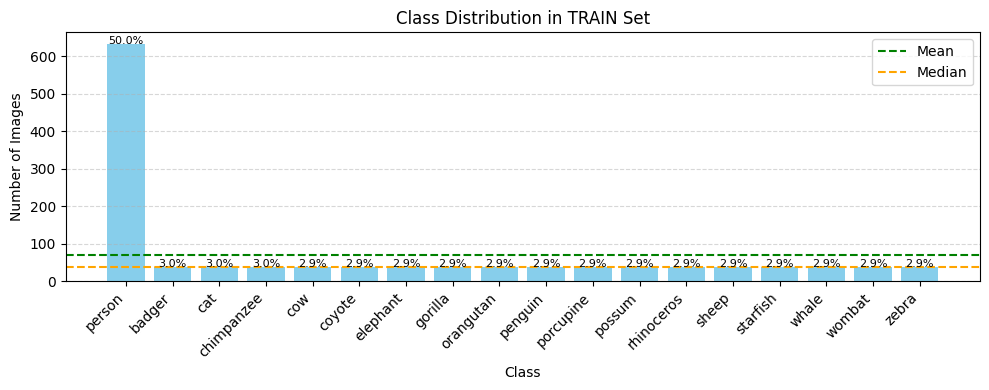


🚨 Class imbalance detected in VALID set:
⚠️ 'badger' is under 5% of valid set (3.1%)
⚠️ 'cat' is under 5% of valid set (2.8%)
⚠️ 'chimpanzee' is under 5% of valid set (3.1%)
⚠️ 'cow' is under 5% of valid set (3.1%)
⚠️ 'coyote' is under 5% of valid set (3.1%)
⚠️ 'elephant' is under 5% of valid set (3.1%)
⚠️ 'gorilla' is under 5% of valid set (3.1%)
⚠️ 'orangutan' is under 5% of valid set (3.1%)
⚠️ 'penguin' is under 5% of valid set (3.1%)
⚠️ 'porcupine' is under 5% of valid set (3.1%)
⚠️ 'possum' is under 5% of valid set (3.1%)
⚠️ 'rhinoceros' is under 5% of valid set (2.8%)
⚠️ 'sheep' is under 5% of valid set (2.8%)
⚠️ 'starfish' is under 5% of valid set (2.8%)
⚠️ 'whale' is under 5% of valid set (2.8%)
⚠️ 'wombat' is under 5% of valid set (2.8%)
⚠️ 'zebra' is under 5% of valid set (2.8%)


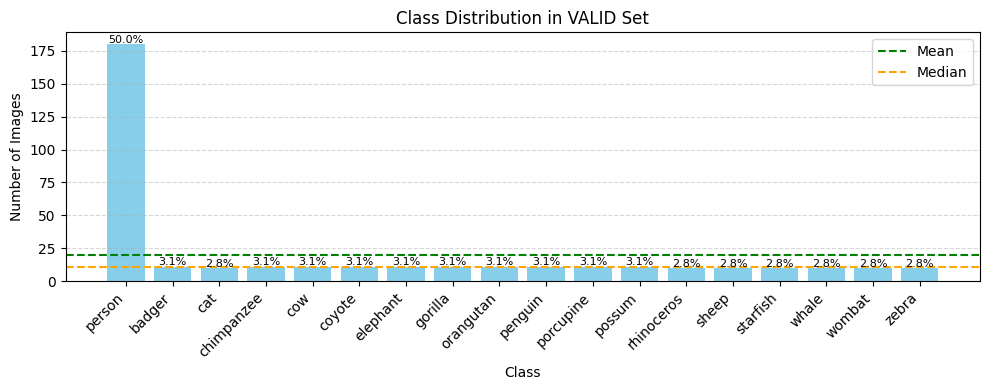


🚨 Class imbalance detected in TEST set:
⚠️ 'badger' is under 5% of test set (2.8%)
⚠️ 'cat' is under 5% of test set (2.8%)
⚠️ 'chimpanzee' is under 5% of test set (2.2%)
⚠️ 'cow' is under 5% of test set (2.8%)
⚠️ 'coyote' is under 5% of test set (2.8%)
⚠️ 'elephant' is under 5% of test set (2.8%)
⚠️ 'gorilla' is under 5% of test set (2.8%)
⚠️ 'orangutan' is under 5% of test set (2.8%)
⚠️ 'penguin' is under 5% of test set (2.8%)
⚠️ 'porcupine' is under 5% of test set (2.8%)
⚠️ 'possum' is under 5% of test set (2.8%)
⚠️ 'rhinoceros' is under 5% of test set (3.3%)
⚠️ 'sheep' is under 5% of test set (3.3%)
⚠️ 'starfish' is under 5% of test set (3.3%)
⚠️ 'whale' is under 5% of test set (3.3%)
⚠️ 'wombat' is under 5% of test set (3.3%)
⚠️ 'zebra' is under 5% of test set (3.3%)


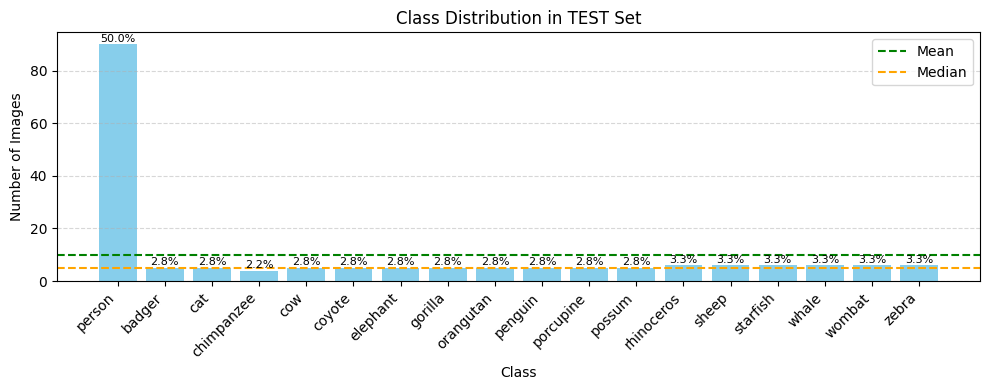

In [13]:
visualize_dataset_stats("data/comboset/dataset_stats.json", save_plots=False, show_pie=False)

# Mean & Std <a id="combo-transforms"></a>

In [14]:
def compute_mean_std(loader):
    n_channels = 3  # 1 for grayscale 3 for RBG
    mean = torch.zeros(n_channels)
    std = torch.zeros(n_channels)
    n_pixels = 0

    # First pass: compute mean
    for data, _ in loader:
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)  # (B, C, H*W)
        mean += data.sum(2).sum(0)
        n_pixels += data.size(2) * batch_samples

    mean /= n_pixels

    # Second pass: compute std using the mean
    for data, _ in loader:
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)
        std += ((data - mean.view(1, -1, 1)) ** 2).sum(2).sum(0)

    std = torch.sqrt(std / n_pixels)
    return mean, std

In [15]:
def get_or_compute_mean_std(loader, save_path='mean_std.pt'):
    if os.path.exists(save_path):
        stats = torch.load(save_path)
        print("Load mean/std via file.")
        return stats['mean'], stats['std'], "loaded"
    else:
        mean, std = compute_mean_std(loader)
        torch.save({'mean': mean, 'std': std}, save_path)
        print("Computed & saved mean/std.")
        return mean, std, "computed"

### Check Images (random) from Train Valid Test

In [ ]:
# Dynamically select a file from each class to confirm train valid test dataset structure:
for split in splits:
    split_path = os.path.join(combo_path, split)

    classes = [cls for cls in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, cls))]
    if not classes:
        print(f"No class folders found in {split_path}")
        continue

    chosen_class = random.choice(classes)
    class_dir = os.path.join(split_path, chosen_class)

    images = os.listdir(class_dir)
    if not images:
        print(f"No images found in {class_dir}")
        continue

    random_file = random.choice(images)
    image_path = os.path.join(class_dir, random_file)

    print(f"🖼️ Showing image from {split.upper()} -> Class: '{chosen_class}' | File: {random_file}")
    img = Image.open(image_path)
    img.show()

# **Classification Or Object Detection Model?**

### Classification Task (e.g., Image Classification)
If your CNN is being used for a classification problem (detecting whether an object is a person or non-person, or multi-class classification), the outputs will likely be logits (raw scores before softmax) from the final layer. You need to convert them to class predictions and compare them with the ground-truth labels.

In [16]:
def calculate_accuracy(outputs, labels):
    """
    Calculate accuracy for a classification CNN model.
    Args:
        outputs (torch.Tensor): Model outputs (logits) of shape [batch_size, num_classes].
        labels (torch.Tensor): Ground truth class labels of shape [batch_size].
    Returns:
        float: Accuracy as a fraction of correct predictions.
    """
    # Get the predicted class with highest probability
    preds = outputs.argmax(dim=1)  # Assuming CrossEntropyLoss
    correct = (preds == labels).sum().item()
    accuracy = correct / labels.size(0)
    return accuracy
    
    # _, preds = torch.max(outputs, dim=1)  # Convert logits to predicted class indices
    # correct = (preds == labels).float()   # Check which predictions are correct
    # return correct.mean()                 # Compute the accuracy

### Regression Task (e.g., Object Detection or Localization)
If your CNN is being used for regression-based tasks (e.g., predicting bounding box coordinates, keypoints, or other continuous outputs), accuracy isn’t meaningful. Instead, you use metrics like Mean Squared Error (MSE) or R² (coefficient of determination).

In [ ]:
def calculate_regression_metrics(outputs, labels):
    """
    Calculate MSE and R² metrics for a regression CNN model.
    Args:
        outputs (torch.Tensor): Model outputs of shape [batch_size, output_dim].
        labels (torch.Tensor): Ground truth values of shape [batch_size, output_dim].
    Returns:
        dict: Dictionary with "MSE" and "R2" scores.
    """
    mse = torch.mean((outputs - labels) ** 2).item()  # Mean Squared Error
    total_variance = torch.mean((labels - labels.mean()) ** 2).item()
    explained_variance = total_variance - mse
    r2_score = explained_variance / total_variance if total_variance > 0 else 0.0
    return {"MSE": mse, "R2": r2_score}

# MixUp Dataset Wrapper

In [17]:
class MixUpDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, alpha=0.2):
        self.dataset = dataset
        self.alpha = alpha
        self.classes = dataset.classes # expose .classes which norm avail through ImageFolder.

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # Sample a second random index
        index2 = torch.randint(0, len(self.dataset), size=(1,)).item()

        (x1, y1) = self.dataset[index]
        (x2, y2) = self.dataset[index2]

        # Apply MixUp formula
        lam = torch.distributions.Beta(self.alpha, self.alpha).sample().item()
        x = lam * x1 + (1 - lam) * x2

        # Convert labels to one-hot if needed
        num_classes = len(self.dataset.classes)
        y1 = F.one_hot(torch.tensor(y1), num_classes=num_classes).float()
        y2 = F.one_hot(torch.tensor(y2), num_classes=num_classes).float()

        y = lam * y1 + (1 - lam) * y2

        return x, y

# Transforms & Loaders <a id="transforms-loaders"></a>

Load mean/std via file.
Loaded Mean: tensor([0.4712, 0.4595, 0.4211])
Loaded Std: tensor([0.2522, 0.2475, 0.2572])
Batch 1: torch.Size([32, 3, 320, 320])
Data loaders calculated mean and std.


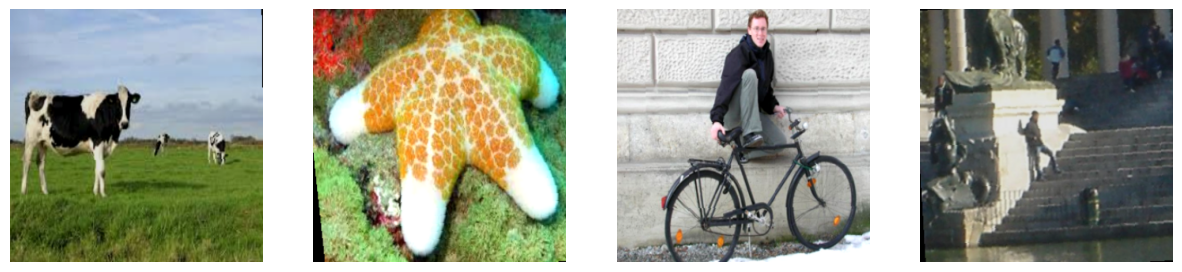

Number of Output Classes: 18


In [18]:
# Define transformations
# utilize dataloader

batch_size = 32  # Set the batch size as per your requirements
val_test_batch_size = 32  # Validation and test batch size
temp_batch_size = 16  # Batch size for mean/std calculation

# Step: Minimal transformation for mean and std calculation
resize_transformation = transforms.Compose([
    transforms.Resize(((320, 320))),  # Ensure consistent resizing
    transforms.ToTensor()           # Convert images to tensors
])

# Temporary DataLoader for calculating mean and std
temp_loader = DataLoader(
    ImageFolder(train_path, transform=resize_transformation),
    batch_size=16, shuffle=False
)

# mean and std of the training dataset
train_mean, train_std, source = get_or_compute_mean_std(temp_loader)
print(f"{source.capitalize()} Mean: {train_mean}")
print(f"{source.capitalize()} Std: {train_std}")

# Data Augmentation for Training Dataset
# Update transformations for training and validation
train_transforms = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # saturation=0.3), # , hue=0.05),
    transforms.RandomResizedCrop(320, scale=(0.80, 1.0)),  # Random crop for zoom effect
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist()),
    # transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Optional: tune ratio
])
val_test_transformation = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())
])

train_dataset = datasets.ImageFolder(root=os.path.join(combo_path, 'train'), transform=train_transforms)

# Count class instances
targets = [label for _, label in train_dataset.imgs]  # List of class labels
class_counts = Counter(targets)

# Calculate class weights (log scaled inverse frequency)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in targets]

# Create sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

val_dataset = datasets.ImageFolder(root=os.path.join(combo_path, 'valid'), transform=val_test_transformation)

# Wrap with MixUp
mixup_dataset = MixUpDataset(train_dataset, alpha=0.4)
train_loader = DataLoader(mixup_dataset, batch_size=batch_size, sampler=sampler, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=val_test_batch_size, shuffle=False)

class_names = train_loader.dataset.classes

# Check the shape of the batches
for i, (data, _) in enumerate(train_loader):
    print(f"Batch {i+1}: {data.shape}")  # Output: (batch_size, channels, height, width)
    if i == 0:  # Check only the first batch
        break

test_loader = DataLoader(
    ImageFolder(os.path.join(combo_path, 'test'), transform=val_test_transformation),
    batch_size=64, shuffle=False
)

print("Data loaders calculated mean and std.")

# Denormalization for visualization
mean = train_mean.tolist()
std = train_std.tolist()


def denormalize(tensor):
    """Denormalize the tensor for visualization."""
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)  # Reverse the normalization
    return tensor

train_dataset_aug = ImageFolder(os.path.join(combo_path, 'train'), transform=train_transforms)

data_iter = iter(DataLoader(train_dataset_aug, batch_size=4, shuffle=True))
images, labels = next(data_iter)

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):  # Show 4 augmented images
    img = denormalize(images[i].clone())
    axes[i].imshow(img.permute(1, 2, 0).numpy())  # (C, H, W) -> (H, W, C)
    axes[i].axis('off')
    
plt.show()

# Set the # of output classes dynamically
out_classes = len(combined_classes)
print(f"Number of Output Classes: {out_classes}")

In [ ]:
gc.collect()
torch.cuda.empty_cache()

# CNN Model <a id="cnn-model"></a>

### Define Class Weights <a id="define-class-weights"></a>
Defining Class Weights prior to the CNN does not affect model initialization.

#### Log-scaled Inverse Frequency Logic - Class Weighting Strategy

In [19]:
# Log-scaled Inverse Frequency - class weighting strategy, others include Inverse Frequency, Inverse √ Frequency
# Extract class labels from the dataset
class_labels = [sample[1] for sample in train_loader.dataset.dataset.samples]

# Count how many samples per class
class_counts = Counter(class_labels)
total_samples = sum(class_counts.values())

# Compute log-scaled inverse frequency weights
log_inv_weights = [math.log(1 + total_samples / class_counts[i]) for i in range(len(class_counts))]
log_inv_weights = torch.tensor(log_inv_weights, dtype=torch.float)
log_inv_weights = log_inv_weights / log_inv_weights.sum()  # Optional: normalize so weights sum to 1
class_weights_tensor = log_inv_weights.to(device)

print(f"Class Weights: {class_weights_tensor}")

Class Weights: tensor([0.0574, 0.0574, 0.0574, 0.0578, 0.0578, 0.0578, 0.0578, 0.0578, 0.0578,
        0.0179, 0.0578, 0.0578, 0.0578, 0.0578, 0.0578, 0.0578, 0.0578, 0.0578],
       device='cuda:0')


#### Visualization Bar Chart - Weights Assigned To Each Class

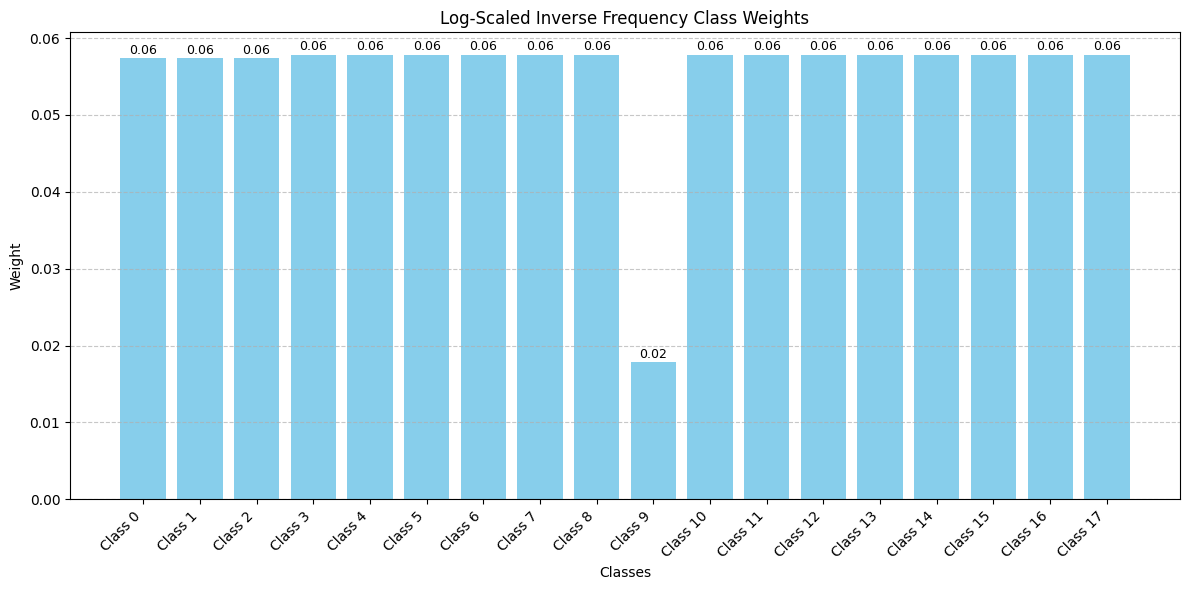

In [20]:
# Load class names if you have them
try:
    with open("class_names.json", "r") as f:
        class_names = json.load(f)
except Exception:
    class_names = [f"Class {i}" for i in range(len(class_weights_tensor))]

# Move weights to CPU if necessary and convert to numpy
weights_np = class_weights_tensor.detach().cpu().numpy()

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(np.arange(len(weights_np)), weights_np, color='skyblue')
plt.xticks(np.arange(len(weights_np)), class_names, rotation=45, ha='right')
plt.xlabel("Classes")
plt.ylabel("Weight")
plt.title("Log-Scaled Inverse Frequency Class Weights")

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Define Lightweight Layer IF cublasLtMatmulAlgoGetHeuristic

In [21]:
# Custom layer to convert tensors to float32 because cublast does not like mix precision.
class ToFloat32(nn.Module):
    def forward(self, x):
        return x.float()

### Define CNN Model Architecture <a id="define-cnn-model"></a>

In [22]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Define the CNN
net = nn.Sequential(
    # First Convolutional Block
    nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.GELU(),
    nn.MaxPool2d(2, 2),
    # Second Convolutional Block
    nn.Conv2d(64, out_channels=128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.GELU(),
    nn.MaxPool2d(2, 2),
    # Third Convolutional Block
    nn.Conv2d(128, out_channels=256, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(256),
    nn.GELU(),
    nn.MaxPool2d(2, 2),
    # Fourth Convolutional Block
    nn.Conv2d(256, out_channels=512, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(512),
    nn.GELU(),
    nn.AdaptiveAvgPool2d((1, 1)), # Reduce to 1x1 spatial dimensions
    # The flatten layer collapses all axes,
    # except the first one, into one axis.
    # Fully Connected Layers
    nn.Flatten(),
    ToFloat32(), # custom class to ensure Float32 for mix precision to avoid cublast error in nn.Seq
    nn.Linear(512, 512), # Input from reduced convolutional output
    nn.LeakyReLU(negative_slope=0.01),
    nn.BatchNorm1d(512),  # Added for extra stability
    nn.Dropout(p=0.3),
    # bottleneck layer
    nn.Linear(512, 256),  # Bottleneck layer
    nn.LeakyReLU(negative_slope=0.01),
    nn.BatchNorm1d(256),
    nn.Dropout(p=0.3),
    nn.Linear(256, out_classes)).to(device)

print(next(net.parameters()).device) 

cuda:0


In [23]:
# Calculate total parameters
total_params = sum(p.numel() for p in net.parameters())
# Calculate trainable parameters
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")

Total Parameters: 1953042
Trainable Parameters: 1953042


### Weights & Biases <a id="weights-biases"></a>

#### Weight Initialization <a id="weight-initialization"></a>

Reset weights after defining classweights.

In [24]:
def reset_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        m.reset_parameters()

Xavier Initialization & Kaiming Initialization

In [25]:
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)  # Xavier initialization
        if m.bias is not None:
            nn.init.zeros_(m.bias)  # Initialize bias to 0
    elif isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        # nn.init.kaiming_normal_(m.weight, nonlinearity='linear')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [26]:
net.apply(reset_weights)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): GELU(approximate='none')
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [27]:
net.apply(weights_init)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): GELU(approximate='none')
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

## Hyperparameters <a id="hyperparameters"></a>

### Loss Function, Optimizer, and Evaluation Metric

Set hyperparameters:
- Epochs to train the model.
- Learning rate of optimization algorithm.
- Accumulation steps.

In [28]:
epochs = 200
learning_rate = 0.001
weight_decay = 1e-5
accumulation_steps = 2

### Loss Function - **Cross Entropy** with optional class weights or **Focal Loss**
__Cross Entropy__ is a loss function thast has common use in Classification. Cross Entropy measures the distance between predicted probability and actual label distribution. This in turn helps with adjusting the weights during model training.

__Focal Point__ is a loss function that is useful in Classification when you have class imbalance. Much like this notebook, it is the merging of two datasets into an imbalanced dataset with person having the same number of images as the 17 animal sets combined. 

In [32]:
# Modified SoftTargetFocalLoss with Label Smoothing Support
class SoftTargetFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean', label_smoothing=0.0, num_classes=None):
        """
        alpha: tensor of shape [num_classes] (optional)
        gamma: focusing parameter for modulating factor
        reduction: 'mean' | 'sum' | 'none'
        label_smoothing: float in [0, 1] applied to soft targets
        num_classes: required for label smoothing
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes

    def forward(self, inputs, targets):
        """
        inputs: [B, C] logits
        targets: [B, C] soft labels (from MixUp or one-hot)
        """
        # Optionally apply label smoothing
        if self.label_smoothing > 0.0:
            assert self.num_classes is not None, "num_classes must be set for label smoothing"
            smooth_val = self.label_smoothing / self.num_classes
            targets = (1.0 - self.label_smoothing) * targets + smooth_val

        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)

        # Focal factor
        focal_factor = (1.0 - probs) ** self.gamma

        # Alpha scaling
        if self.alpha is not None:
            alpha = self.alpha.view(1, -1)  # [1, C]
            focal_loss = -alpha * focal_factor * targets * log_probs
        else:
            focal_loss = -focal_factor * targets * log_probs

        loss = focal_loss.sum(dim=1)  # sum over classes

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

In [33]:
criterion = SoftTargetFocalLoss(alpha=class_weights_tensor.to(device), gamma=2.0,reduction='mean', label_smoothing=0.1, num_classes=out_classes)

## Mixed Precision Training - Autocast & GradScaler

### **Optimizer & Learning Rate Scheduler**

__SGD (Stochastic Gradient Descent)__ - Basic optimization algorithm that updates model parameters using the gradient of the loss function. It uses a constant learning rate unless explicitly adjusted through a scheduler.

__Adam (Adaptive Moment Estimation)__ - Dynamic optimization algorithm that adjusts learning rates for each parameter individually using moving averages of gradients and their squared values.

__AdamW (Adaptive Moment Estimation with Weight Decay)__ - Dynamic optimization algorithm. AdamW is like Adam but with weight decay. It works in weight decay seperate from the training model in a bid to not allow overfitting, How? By reducing parameter size during training.

In [34]:
def get_optimizer(model, lr, weight_decay):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if "bias" in name or "bn" in name or "BatchNorm" in name:
            no_decay.append(param)
        else:
            decay.append(param)
    return torch.optim.AdamW([
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0}
    ], lr=lr)

In [35]:
optimizer = get_optimizer(net, learning_rate, weight_decay=weight_decay
scaler = torch.cuda.amp.GradScaler()
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=True)

## Profile Memory Usage <a id="profile-memory"></a>
Use PyTorch's profiler to identify which part of your code is consuming the most memory:

In [ ]:
# from torch.profiler import profile, record_function, ProfilerActivity
# from torchvision.transforms import ToTensor

# # Assuming `train_loader` is your DataLoader
# data_iter = iter(train_loader)  # Get an iterator for the DataLoader
# data, labels = next(data_iter)  # Retrieve a batch of data and labels

# # Move the data and labels to the device
# data = data.to(device)
# labels = labels.to(device)

# # Profile the model
# with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:
#     with record_function("model_training"):
#         output = net(data)  # Forward pass through the model

# # Print profiling results
# print(prof.key_averages().table(sort_by="cuda_time_total"))

# Training CNN Model <a id="training-model"></a>

Training - during an epoch there is forward propogation, loss calculation, backward propogation and weight update

In [36]:
gc.collect()  # Clean up Python garbage
torch.cuda.empty_cache()  # Clear GPU Memory Before Training

# Optional sanity check
print(torch.cuda.memory_allocated() / 1024**2, "MB allocated")
print(torch.cuda.memory_reserved() / 1024**2, "MB reserved")

start_time = time.time()

optimizer.zero_grad()  # init gradients out of loop

# Initialize lists to store loss values
train_losses = []
val_losses = []
train_accs = []
valid_accs = []

best_val_acc = 0.0 # To save best epoch produced as opposed to the last ran iteration.
patience = 20 # 20 epochs iteration grace for stagnant training before ending training.
epoch_noimprove = 0 # counter used for the number of epochs with no improvements.
val_f1s = []  # to store F1-score per epoch
best_val_f1 = 0.0 # Track best F1 for scheduler + model saving

lrs = []

for epoch in range(epochs):
    net.train()  # Activate training mode
    train_loss, train_acc = 0., 0.
    val_loss, valid_acc = 0., 0.
    for i, (data, label) in enumerate(train_loader):
        data, label = data.to(device), label.to(device)

        # Mixed precision forward pass
        with autocast():  # Enable mixed precision
            output = net(data)
            loss = criterion(output, label)

        # Check for NaNs or Infs in loss
        if not torch.isnan(loss).any() and not torch.isinf(loss).any():
            scaler.scale(loss).backward()

            # Only unscale + clip + step during accumulation step
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)

                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
        else:
            print(f"[Epoch {epoch+1}, Step {i+1}] Skipped due to invalid loss")

        # Soft-label -> hard label for accuracy
        true_labels = label.argmax(dim=1)
        pred_labels = output.argmax(dim=1)

        train_acc += (pred_labels == true_labels).sum().item() / len(label)
        train_loss += loss.item()

        del data, label, output, loss
        torch.cuda.empty_cache()

    # avg training metrics for the epoch
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)

    # Initialize precision-recall trackers
    all_preds = []
    all_labels = []
    all_probs = []  # shape [N, num_classes]
    
    # Validation Loop
    net.eval()  # Activate evaluation mode
    val_loss, valid_acc = 0., 0.    
    
    with torch.no_grad():
        for data, label in val_loader:
            data, label = data.to(device), label.to(device)

            with autocast():  # Mixed precision for validation
                output = net(data)
            
                # Convert hard labels to one-hot for soft-target loss
                num_classes = output.size(1)
                soft_labels = F.one_hot(label, num_classes=num_classes).float()

                loss = criterion(output, soft_labels)

            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

            probs = torch.softmax(output, dim=1)
            all_probs.append(probs.cpu())

            valid_acc += calculate_accuracy(output, label)
            val_loss += loss.item()

            del data, label, output, loss, probs
            torch.cuda.empty_cache()


    # Average validation metrics for the epoch
    val_loss /= len(val_loader)
    valid_acc /= len(val_loader)
    
    # Calculate precision and recall
    # Check Predictions Before Calculating Metrics
    if len(set(all_preds)) > 1:  # Ensure there are predictions for at least 2 classes
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=1)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=1)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=1)
    else:  # If no valid predictions, set precision and recall to 0.0
        precision = recall = f1 = 0.0

    val_f1s.append(f1)  # Track F1 over time
    
    # Log metrics for the epoch
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    valid_accs.append(valid_acc)

    # Log current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    lrs.append(current_lr)
    print(f"Epoch {epoch+1} - Learning Rate: {current_lr:.6f}")
    
    # Adjust learning rate
    scheduler.step(valid_acc)
    # scheduler.step(f1)

    print("Epoch %d: train loss %.3f, train acc %.3f, val loss %.3f, val acc %.3f, precision %.3f, recall %.3f, F1-score %.3f" % (
    epoch+1, train_loss, train_acc, val_loss, valid_acc, precision, recall, f1))
    # save best validation accuracy
    if valid_acc > best_val_acc + 1e-4:
        best_val_acc = valid_acc
        epoch_noimprove = 0 # counter reset in loop
        torch.save(net.state_dict(), "cap_model_weights_best.pth")
        # print(f"Best model saved at epoch {epoch+1} val acc: {valid_acc:.3f}")
    else:
       epoch_noimprove += 1 
    if f1 > best_val_f1 + 1e-4:
        best_val_f1 = f1
        epoch_noimprove = 0
        torch.save(net.state_dict(), "best_model_by_f1.pth")
    # else:
    #    epoch_noimprove += 1
    if epoch_noimprove >= patience:
        print("Early stop no improvement in %d epochs." % patience)
        break  # exit stagnant training

    # Clear GPU memory CUDA needs the memory
    torch.cuda.empty_cache()

print(f"\nTraining finished in {(time.time() - start_time)/60:.2f} minutes.")

7.46875 MB allocated
22.0 MB reserved
Epoch 1 - Learning Rate: 0.001000
Epoch 1: train loss 0.148, train acc 0.114, val loss 0.147, val acc 0.141, precision 0.409, recall 0.108, F1-score 0.335
Epoch 2 - Learning Rate: 0.001000
Epoch 2: train loss 0.135, train acc 0.180, val loss 0.093, val acc 0.432, precision 0.298, recall 0.261, F1-score 0.422
Epoch 3 - Learning Rate: 0.001000
Epoch 3: train loss 0.129, train acc 0.192, val loss 0.097, val acc 0.289, precision 0.219, recall 0.250, F1-score 0.390
Epoch 4 - Learning Rate: 0.001000
Epoch 4: train loss 0.123, train acc 0.197, val loss 0.090, val acc 0.380, precision 0.227, recall 0.284, F1-score 0.384
Epoch 5 - Learning Rate: 0.001000
Epoch 5: train loss 0.119, train acc 0.241, val loss 0.085, val acc 0.419, precision 0.306, recall 0.299, F1-score 0.405
Epoch 6 - Learning Rate: 0.001000
Epoch 6: train loss 0.114, train acc 0.287, val loss 0.088, val acc 0.414, precision 0.193, recall 0.260, F1-score 0.476
Epoch 7 - Learning Rate: 0.00100

# Save Metadata Alongside Best Weights

In [ ]:
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': net.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'best_val_f1': best_val_f1,
    'val_f1s': val_f1s,
    'train_accs': train_accs,
    'valid_accs': valid_accs,
    'train_losses': train_losses,
    'val_losses': val_losses,
    # 'confusion_matrix': conf_matrix,  # if you're calculating this in loop
}, "best_model_checkpoint.pt")

# Save Summary & Classification Report

In [37]:
# JSON - summary, classification report
summary = {
    "best_val_acc": best_val_acc,
    "best_val_f1": best_val_f1,
    "epochs_run": epoch + 1,
    "train_acc_final": train_accs[-1],
    "val_acc_final": valid_accs[-1],
    "train_loss_final": train_losses[-1],
    "val_loss_final": val_losses[-1],
    "training_time_min": round((time.time() - start_time)/60, 2),
    "learning_rate_end": optimizer.param_groups[0]["lr"],
    "optimizer": str(optimizer.__class__.__name__),
    "criterion": str(criterion),
    "label_smoothing": getattr(criterion, "label_smoothing", "N/A"),
}

with open("training_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

# 2. Save classification report (use your test set preds/labels here)
cls_report = classification_report(y_true=all_labels, y_pred=all_preds, output_dict=True)
with open("classification_report.json", "w") as f:
    json.dump(cls_report, f, indent=4)

# Auto-Create Config

In [ ]:
# Auto-create config dict based on actual values used in this run
config = {
    "training": {
        "epochs": epochs,
        "batch_size": batch_size,
        "val_test_batch_size": val_test_batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "accumulation_steps": accumulation_steps,
        "label_smoothing": label_smoothing,
        "use_amp": use_amp,
        "early_stopping_patience": patience
    },
    "scheduler": {
        "type": "ReduceLROnPlateau",
        "mode": "max",
        "factor": 0.5,
        "patience": 5
    },
    "loss": {
        "type": "SoftTargetFocalLoss",
        "gamma": 2.0,
        "class_weights": "log_inverse_frequency",
        "reduction": "mean",
        "label_smoothing": label_smoothing
    },
    "mixup": {
        "enabled": True,
        "alpha": mixup_alpha,
        "stop_epoch": 60
    },
    "optimizer": {
        "type": "AdamW",
        "decoupled_weight_decay": True
    },
    "dataset": {
        "path": "data/comboset",
        "input_size": [320, 320],
        "normalization": {
            "mean": [0.4712, 0.4595, 0.4211],
            "std": [0.2522, 0.2475, 0.2572]
        },
        "augmentation": [
            {"random_horizontal_flip": 0.5},
            {"random_rotation": 15},
            {"color_jitter": {
                "brightness": 0.2,
                "contrast": 0.2
            }},
            {"random_resized_crop": {
                "scale": [0.8, 1.0]
            }}
        ]
    },
    "output": {
        "save_best_by": "val_f1",
        "save_dir": "outputs/"
    }
}

In [ ]:
# Auto-export YAML to archive config used for this run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
with open(f"outputs/config_used_{timestamp}.yaml", "w") as f:
    yaml.dump(config, f, sort_keys=False)

print(f"Config archived as outputs/config_used_{timestamp}.yaml")

# Log Training History

In [ ]:
def log_training_history(train_losses, val_losses, train_accs, valid_accs, val_f1s, lrs, 
                         best_val_acc, best_val_f1, early_stop_epoch,
                         seed, learning_rate, weight_decay, batch_size, epochs, 
                         filename_prefix="training_history"):
    
    now = datetime.now()
    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")

    training_history = {
        "timestamp": timestamp,
        "start_time": start_time,
        "end_time": time.time(),
        "duration_minutes": round((time.time() - start_time) / 60, 2),
        "epochs_ran": early_stop_epoch,
        "seed": seed,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "accumulation_steps": accumulation_steps,
        "best_val_acc": round(best_val_acc, 4),
        "best_val_f1": round(best_val_f1, 4),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "valid_accs": valid_accs,
        "val_f1s": val_f1s,
        "learning_rates": lrs,
    }

    # Save as PyTorch binary
    torch.save(training_history, f"{filename_prefix}_{timestamp}.pt")

    # Save as JSON (converted to plain floats for compatibility)
    clean_for_json = {
        k: [float(x) for x in v] if isinstance(v, list) else v
        for k, v in training_history.items()
    }
    with open(f"{filename_prefix}_{timestamp}.json", "w") as f:
        json.dump(clean_for_json, f, indent=4)

    print(f"✅ Training log saved to:\n- {filename_prefix}_{timestamp}.pt\n- {filename_prefix}_{timestamp}.json")

In [ ]:
log_training_history(
    train_losses, val_losses, train_accs, valid_accs, val_f1s, lrs,
    best_val_acc, best_val_f1, epoch+1,
    seed,
    config["training"]["learning_rate"],
    config["training"]["weight_decay"],
    config["training"]["batch_size"],
    config["training"]["epochs"],
    config["training"]["accumulation_steps"]
)

# Create ChangeLog

In [ ]:
# Create changelog dict
changelog = {
    "run_id": "exp_2025_04_19_v1",
    "date": "2025-04-19",
    "goal": "Reach 80% validation accuracy with CosineAnnealingWarmRestarts + AdamW",
    "notes": [
        "Updated MixUp alpha to 0.2",
        "Changed weight_decay from 5e-5 to 1e-5",
        "Restored label_smoothing to 0.1",
        "Switched scheduler from OneCycleLR to CosineAnnealingWarmRestarts"
    ],
    "hyperparameters": config["training"] | config["optimizer"] | config["scheduler"] | {
        "mixup_alpha": config["mixup"]["alpha"],
        "label_smoothing": config["loss"]["label_smoothing"],
        "model_arch": "Custom CNN"
    }
}

In [ ]:
def log_experiment_metadata(changelog, base_name="changelog"):
    with open(f"{base_name}.json", "w") as f_json:
        json.dump(changelog, f_json, indent=4)
    with open(f"{base_name}.yaml", "w") as f_yaml:
        yaml.dump(changelog, f_yaml, sort_keys=False)
    print(f"✅ Changelog saved as {base_name}.json and {base_name}.yaml")
    
# log_experiment_metadata(changelog)

In [ ]:
log_experiment_metadata(changelog)

# Create ChangeLog & Config

In [ ]:
# Create timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = "outputs"
os.makedirs(save_dir, exist_ok=True)

# === CONFIG DICT (Reflecting actual run values) ===
config = {
    "training": {
        "epochs": epochs,
        "batch_size": batch_size,
        "val_batch_size": val_test_batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "accumulation_steps": accumulation_steps,
        "label_smoothing": label_smoothing,
        "use_amp": use_amp,
        "early_stopping_patience": patience
    },
    "scheduler": {
        "type": "CosineAnnealingWarmRestarts",
        "T_0": 8,
        "T_mult": 2,
        "eta_min": 1e-6
    },
    "loss": {
        "type": "SoftTargetFocalLoss",
        "gamma": 2.0,
        "class_weights": "log_inverse_frequency",
        "reduction": "mean"
    },
    "mixup": {
        "enabled": True,
        "alpha": mixup_alpha,
        "stop_epoch": 60
    },
    "optimizer": {
        "type": "AdamW",
        "decoupled_weight_decay": True
    },
    "dataset": {
        "path": combo_path,
        "input_size": [320, 320],
        "normalization": {
            "mean": train_mean.tolist(),
            "std": train_std.tolist()
        }
    },
    "output": {
        "save_best_by": "val_f1",
        "save_dir": save_dir
    }
}

# === CHANGELOG DICT ===
changelog = {
    "run_id": f"exp_{timestamp}",
    "date": datetime.now().strftime("%Y-%m-%d"),
    "goal": "Reach 80% validation accuracy with CosineAnnealingWarmRestarts + AdamW",
    "notes": [
        "Updated MixUp alpha to 0.2",
        "Changed weight_decay from 5e-5 to 1e-5",
        "Restored label_smoothing to 0.1",
        "Switched scheduler from OneCycleLR to CosineAnnealingWarmRestarts"

    ],
    "hyperparameters": {
        "model_arch": "Custom CNN",
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "label_smoothing": label_smoothing,
        "mixup_alpha": mixup_alpha,
        "scheduler": "ReduceLROnPlateau",
        "optimizer": "AdamW",
        "batch_size": batch_size,
        "epochs": epochs,
        "accumulation_steps": accumulation_steps
    }
}

# === SAVE YAML & JSON LOG FILES ===
with open(f"{save_dir}/changelog_{timestamp}.yaml", "w") as f_yaml:
    yaml.dump(changelog, f_yaml, sort_keys=False)

with open(f"{save_dir}/changelog_{timestamp}.json", "w") as f_json:
    json.dump(changelog, f_json, indent=4)

with open(f"{save_dir}/config_used_{timestamp}.yaml", "w") as f_config:
    yaml.dump(config, f_config, sort_keys=False)

print(f"✅ Changelog + config saved to:\n- {save_dir}/changelog_{timestamp}.yaml\n- {save_dir}/config_used_{timestamp}.yaml")

In [ ]:
# Load best model weights
# net.load_state_dict(torch.load("cap_model_weights_best.pth"))
# net.to(device)
# net.eval()

#  **Save Model Weights** or **Save Model** of Training

.pt for pytorch & .pth for pytorch hierarchy

In [ ]:
torch.save(net.state_dict(), "cap_model_weights.pth")

In [ ]:
# save entire model and contents such as arch and weights
torch.save(net, "cap_model_full.pth")

In [ ]:
torch.save(net.state_dict(), "cap_model_weights.pt")

In [ ]:
# save entire model and contents such as arch and weights
torch.save(net, "cap_model_full.pt")

#  **Test Accuracy** of CNN Training <a id="test-accuracy"></a>

In [38]:
test_acc = 0.
net.eval() # Activate evaluation mode
with torch.no_grad():

    with torch.no_grad():
        for data, label in test_loader:
            data = data.to(device)
            label = label.to(device)
            # Make forward pass with the trained model so far
            output = net(data)
            # Accumulate validation accuracy and loss
            test_acc += calculate_accuracy(output, label)

test_acc = test_acc/len(test_loader)

print("Test accuracy: %.3f" % test_acc)

Test accuracy: 0.706


# **Visualizations** <a id="visualizations"></a>

## Metrics

### **Summary - everything** <a id="summary"></a>

See what is happening with your training model

In [ ]:
summary(net, input_size=(3, 320, 320))

### Evaluate Per Class Metrics

In [39]:
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=1))

              precision    recall  f1-score   support

     Class 0       0.25      0.09      0.13        11
     Class 1       0.50      0.70      0.58        10
     Class 2       0.40      0.36      0.38        11
     Class 3       0.67      0.73      0.70        11
     Class 4       0.38      0.45      0.42        11
     Class 5       0.43      0.55      0.48        11
     Class 6       0.25      0.27      0.26        11
     Class 7       0.70      0.64      0.67        11
     Class 8       0.50      0.64      0.56        11
     Class 9       0.99      0.87      0.93       180
    Class 10       0.36      0.73      0.48        11
    Class 11       0.33      0.09      0.14        11
    Class 12       0.50      0.60      0.55        10
    Class 13       0.42      0.50      0.45        10
    Class 14       0.70      0.70      0.70        10
    Class 15       0.40      0.80      0.53        10
    Class 16       0.30      0.30      0.30        10
    Class 17       0.90    

### Model Performance Function <a id="model-performance"></a>

In [40]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    test_loss = 0.0

    with torch.no_grad():  # Disable gradient computation
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)  # Forward pass
            # loss = criterion(outputs, labels)

            # Convert hard labels to one-hot
            num_classes = outputs.size(1)
            # one_hot_labels = F.one_hot(labels, num_classes=num_classes).float()

            # Auto-handle both hard (class index) and soft (one-hot) labels
            if labels.ndim == 1:
                one_hot_labels = F.one_hot(labels, num_classes=num_classes).float()
            else:
                one_hot_labels = labels

            loss = criterion(outputs, one_hot_labels)
            test_loss += loss.item()

            # _, preds = torch.max(outputs, 1)  # Get predicted classes
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            # all_labels.extend(labels.cpu().numpy())
            all_labels.extend(labels.argmax(dim=1).cpu().numpy() if labels.ndim > 1 else labels.cpu().numpy()) # Handle soft labels (e.g., from MixUp) & Handle hard labels (normal test set)

    conf_matrix = confusion_matrix(all_labels, all_preds)
    class_report = classification_report(all_labels, all_preds, zero_division=0)
    test_accuracy = accuracy_score(all_labels, all_preds)

    return conf_matrix, class_report, test_accuracy, test_loss / len(dataloader)  # Function ends here

# Evaluate the model
conf_matrix, class_report, test_accuracy, avg_loss = evaluate_model(
    model=net,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

In [41]:
# Print results
print("Model performance on the test set:")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Average Test Loss: {avg_loss:.4f}")

Model performance on the test set:
Confusion Matrix:
[[ 3  1  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  3  0  0  1  0  0  0  0  0  0  1  0  0  0  0  0  0]
 [ 0  0  2  0  0  1  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  2  0  1  0  0  0  0  0  0  0  1  0  0  0  0]
 [ 0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  1  1]
 [ 0  0  0  0  0  3  0  0  0  0  0  0  2  0  0  0  0  0]
 [ 0  1  0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  4  0  0  1  0  0  0  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  3  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  4  1  0  1 80  2  0  0  0  1  1  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  4  0  0  0  0  0  0  1]
 [ 2  0  0  0  0  0  0  0  0  0  1  1  0  1  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  3  0  0  1  1  0]
 [ 1  0  0  0  2  0  0  0  1  0  0  0  0  1  1  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  0  1  1  0  1  2  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  6  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  1 

#### Debugging Check class representation in the dataset

In [ ]:
print(Counter(all_preds))  # See how often each class is predicted

#### Debugging Print out some of the test images the model predicted as class 0

In [ ]:
for i, (true, pred) in enumerate(zip(all_labels, all_preds)):
    if pred == 0:
        print(f"Sample {i}: True Label = {true}, Pred = {pred}")
        # Optional: save or show image here

In [ ]:
# Visual Inspection for Misclassified Images
# Assuming you have access to the dataset paths
for i, (img, label) in enumerate(test_loader.dataset):
    pred = all_preds[i]
    true = all_labels[i]
    if pred == 0:
        plt.imshow(img.permute(1, 2, 0))  # Convert CHW -> HWC
        plt.title(f"True: {true}, Pred: {pred}")
        plt.axis("off")
        plt.show()

## Visuals

### Visualization of Learning Rate

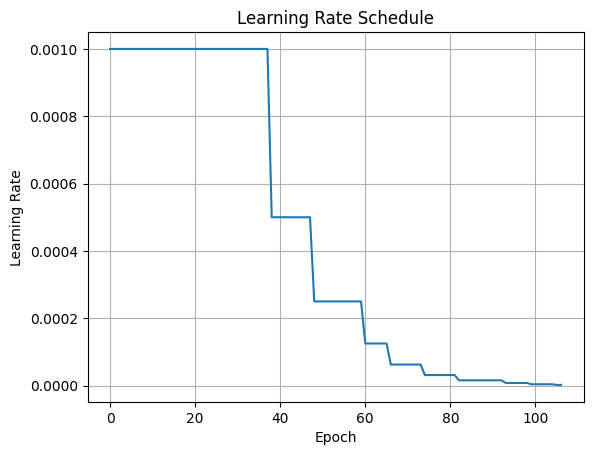

In [42]:
plt.plot(lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

### Validation F1-Score over Epochs

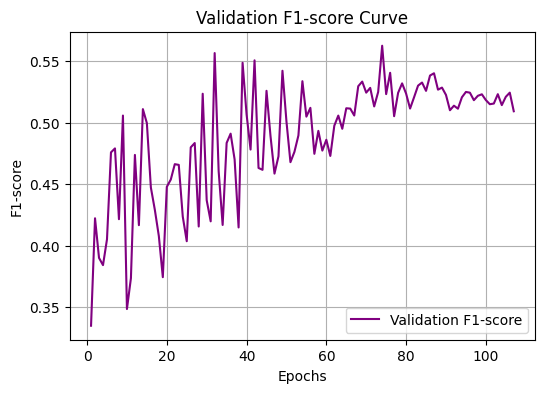

In [43]:
# Validation F1-Score over epochs
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(val_f1s) + 1), val_f1s, label="Validation F1-score", color='purple')
plt.xlabel("Epochs")
plt.ylabel("F1-score")
plt.title("Validation F1-score Curve")
plt.legend()
plt.grid(True)
plt.show()

### Training & Validation Curves <a id="training-validation-curves"></a>

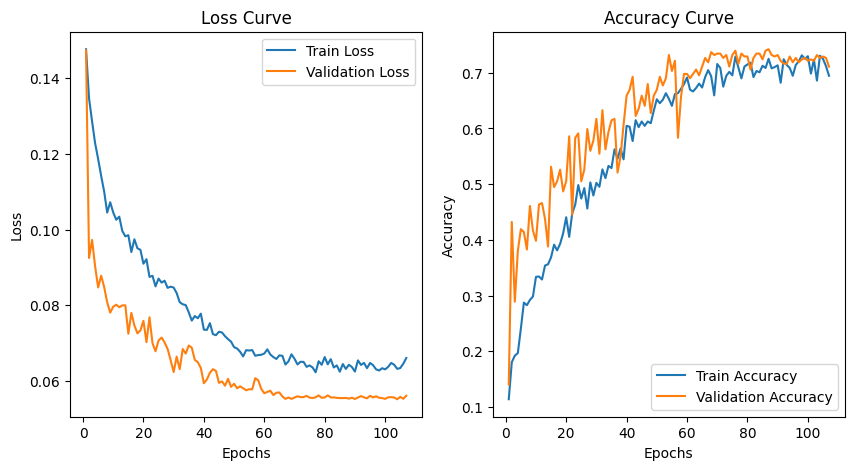

In [44]:
# Find the minimum length among all lists
min_epochs = min(len(train_losses), len(val_losses), len(train_accs), len(valid_accs))

# Plot Loss and Accuracy
plt.figure(figsize=(10, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, min_epochs + 1), train_losses[:min_epochs], label="Train Loss")
plt.plot(range(1, min_epochs + 1), val_losses[:min_epochs], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, min_epochs + 1), train_accs[:min_epochs], label="Train Accuracy")
plt.plot(range(1, min_epochs + 1), valid_accs[:min_epochs], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

### Training & Validation Loss Plots <a id="training-validation-loss"></a>

In [45]:
def plot_losses(train_losses, val_losses, train_acc, valid_acc):
    plt.plot(train_losses, label="Training Loss", color="blue")
    plt.plot(val_losses, label="Validation Loss", color="orange")
    plt.title("Loss values")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.plot(train_acc, "g", label="Train Accuracy")
    plt.plot(valid_acc, "red", label="Validation Accuracy")
    plt.title("Accuracy values")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

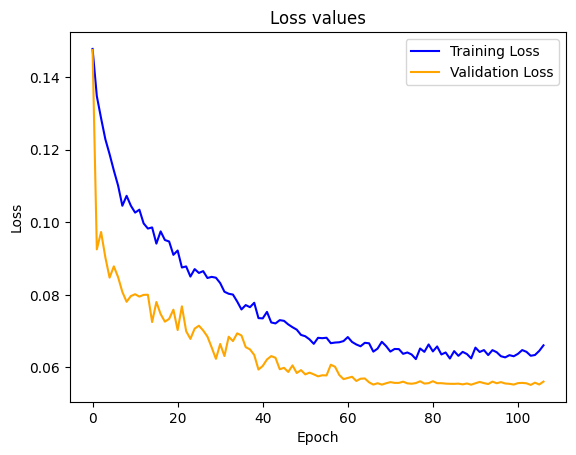

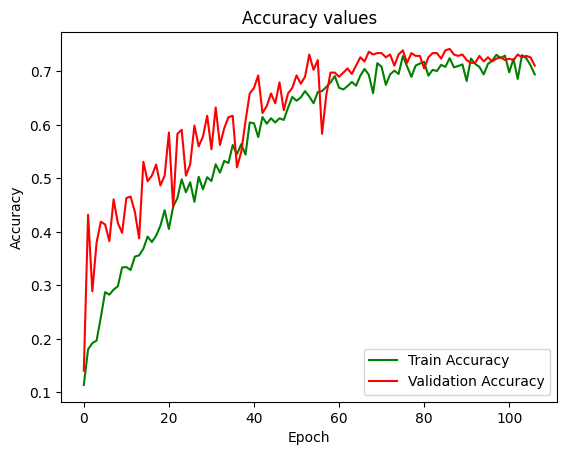

In [46]:
# train loss function and accuracy plot
plot_losses(train_losses, val_losses, train_accs, valid_accs)

### Confusion Matrices <a id="confusion-matrices"></a>

Confusion Matrix:
[[  2   0   4   0   4   0   6   0   0   0   2   0   0   2   0   0   2   0]
 [  0  14   0   2   0   0   0   0   2   0   0   0   0   0   0   0   2   0]
 [  2   4   8   0   0   0   8   0   0   0   0   0   0   0   0   0   0   0]
 [  2   0   0  16   0   2   0   0   0   0   0   0   0   2   0   0   0   0]
 [  0   0   0   0  10   0   2   0   0   0   6   0   0   2   0   0   2   0]
 [  0   0   0   2   0  12   0   0   0   0   2   0   6   0   0   0   0   0]
 [  0   0   8   0   2   0   6   0   0   0   4   0   2   0   0   0   0   0]
 [  0   2   0   2   0   0   0  14   0   2   0   2   0   0   0   0   0   0]
 [  0   0   0   0   0   2   0   0  14   0   0   2   0   2   0   2   0   0]
 [  0   0   0   2   0   3   0   2   6 312   4   0   4   0   1  22   4   0]
 [  0   0   0   0   2   0   0   0   0   0  16   0   0   2   2   0   0   0]
 [  2   4   0   0   2   0   2   2   0   0   0   2   0   2   4   0   2   0]
 [  0   0   0   0   0   6   0   0   0   0   0   0  12   0   0   0   0   2]
 [  0  

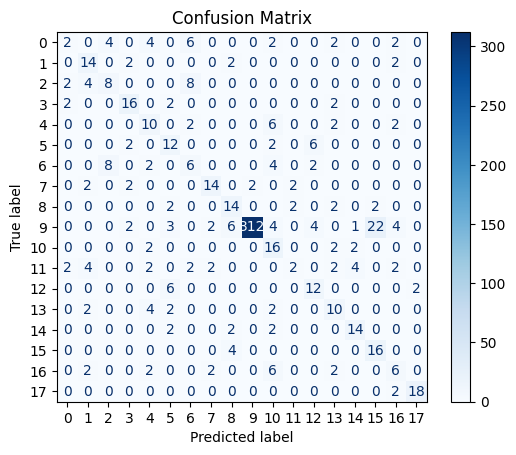

In [47]:
# Validation loop to collect predictions & labels
net.eval()  # Set model to evaluation mode
with torch.no_grad():
    for data, label in val_loader:
        data, label = data.to(device), label.to(device)

        # Forward pass
        output = net(data)

        # Get predictions
        preds = output.argmax(1)

        # Store predictions and labels
        all_preds.extend(preds.cpu().numpy())  # Move to CPU and convert to numpy
        all_labels.extend(label.cpu().numpy())  # Move to CPU and convert to numpy

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(out_classes))

# Print confusion matrix txt file
print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(out_classes))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Confusion Matrix (Raw Counts):
[[  2   0   4   0   4   0   6   0   0   0   2   0   0   2   0   0   2   0]
 [  0  14   0   2   0   0   0   0   2   0   0   0   0   0   0   0   2   0]
 [  2   4   8   0   0   0   8   0   0   0   0   0   0   0   0   0   0   0]
 [  2   0   0  16   0   2   0   0   0   0   0   0   0   2   0   0   0   0]
 [  0   0   0   0  10   0   2   0   0   0   6   0   0   2   0   0   2   0]
 [  0   0   0   2   0  12   0   0   0   0   2   0   6   0   0   0   0   0]
 [  0   0   8   0   2   0   6   0   0   0   4   0   2   0   0   0   0   0]
 [  0   2   0   2   0   0   0  14   0   2   0   2   0   0   0   0   0   0]
 [  0   0   0   0   0   2   0   0  14   0   0   2   0   2   0   2   0   0]
 [  0   0   0   2   0   3   0   2   6 312   4   0   4   0   1  22   4   0]
 [  0   0   0   0   2   0   0   0   0   0  16   0   0   2   2   0   0   0]
 [  2   4   0   0   2   0   2   2   0   0   0   2   0   2   4   0   2   0]
 [  0   0   0   0   0   6   0   0   0   0   0   0  12   0   0   0   0

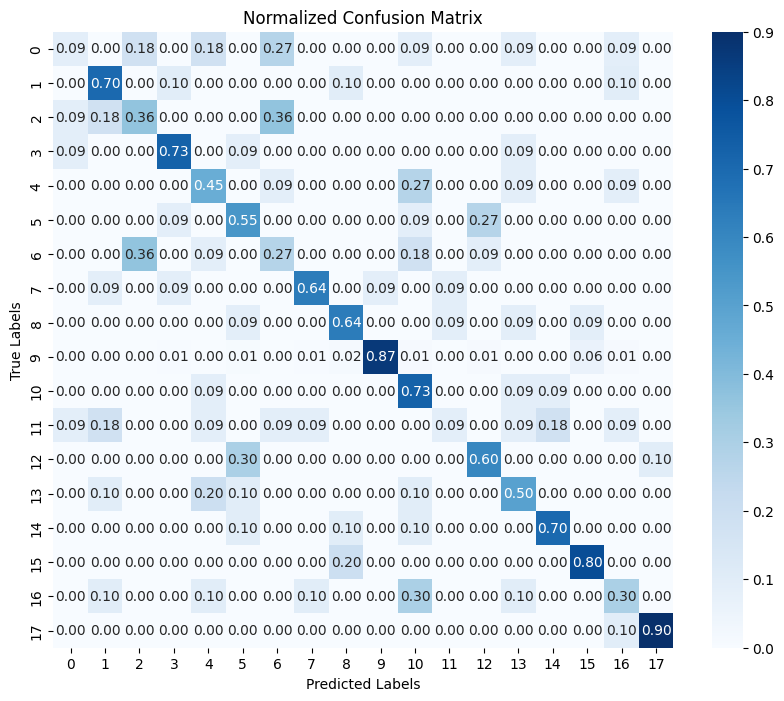

In [48]:
# Heatmap-style confusion matrix with correct predictions on diagonal and misclassifications in the off-diagonal entries.
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=range(out_classes))

# Check for empty rows
print("Confusion Matrix (Raw Counts):")
print(cm)

# Normalize the confusion matrix
cm_sum = cm.sum(axis=1)[:, np.newaxis]  # Sum of each row
cm_normalized = np.divide(cm.astype('float'), cm_sum, where=cm_sum != 0)  # Avoid division by zero
cm_normalized = np.nan_to_num(cm_normalized)  # Replace NaN with 0

# Create a heatmap
plt.figure(figsize=(10, 8))  # Adjust size as needed
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=range(out_classes), yticklabels=range(out_classes))

# Add titles and labels
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

### Feature Maps <a id="feature-maps"></a>

In [ ]:
# Forward pass to extract feature maps
def visualize_feature_maps(model, input_image):
    model.eval()
    layers = list(model.children())[:-1]  # Exclude the final fully connected layer
    for idx, layer in enumerate(layers):
        input_image = layer(input_image)
        if isinstance(layer, nn.Conv2d):  # Visualize only Conv layers
            plt.figure(figsize=(15, 10))
            for i in range(min(8, input_image.size(1))):  # Show up to 8 feature maps
                plt.subplot(2, 4, i+1)
                plt.imshow(input_image[0, i].detach().cpu().numpy(), cmap="viridis")
                plt.axis("off")
            plt.suptitle(f"Feature Maps after Layer {idx + 1}")
            plt.show()

# Dummy input
dummy_input = torch.randn(1, 3, 320, 320).to(device)
visualize_feature_maps(net, dummy_input)

### Kernel/Visualizations <a id="kernel-visualizations"></a>

In [ ]:
# Extract weights from the first convolutional layer
filters = net[0].weight.data.cpu()  # The first Conv2D layer is at index 0 in nn.Sequential

# Plot filters
fig, axes = plt.subplots(4, 8, figsize=(12, 6))  # Adjust rows/columns as needed
for i, ax in enumerate(axes.flat):
    if i < filters.size(0):  # Ensure not to exceed the number of filters
        ax.imshow(filters[i].permute(1, 2, 0).numpy(), cmap='viridis')  # Convert from (C, H, W) to (H, W, C)
        ax.axis("off")
plt.suptitle("Filters in the First Convolutional Layer")
plt.show()


### Gradient Visualization <a id="gradient-visualizations"></a>

In [ ]:
def visualize_gradients(model, input_image, target_label):
    input_image.requires_grad = True
    model.eval()
    output = model(input_image)
    loss = nn.CrossEntropyLoss()(output, target_label)
    loss.backward()
    gradients = input_image.grad.data.cpu().numpy()[0]
    
    # Normalize gradients for visualization
    gradients = (gradients - gradients.min()) / (gradients.max() - gradients.min())
    
    # Visualize gradients
    plt.imshow(gradients.transpose(1, 2, 0), cmap="viridis")  # Adjust for RGB channels
    plt.title("Gradients Visualization")
    plt.axis("off")
    plt.show()

# Dummy input
dummy_input = torch.randn(1, 3, 320, 320).to(device)
dummy_target = torch.tensor([0]).to(device)  # Replace with
visualize_gradients(net, dummy_input, dummy_target)

### CAM/Grad-CAM <a id="cam-grad-cam"></a>

In [ ]:
print(net)  # Or print(net.features) in cases that it's wrapped

In [ ]:
images, labels = next(iter(val_loader)) # selects a batch from val data loader

# Choose a sample index 0 or change as desired
image = images[0]
label = labels[0].item()

# Create an input tensor (example input size: 640x640)
input_tensor = image.unsqueeze(0).to(device)  # shape: [1, 3, 320, 320]

# Normalize the input tensor using the mean and std used during training
# mean = [0.4713, 0.4595, 0.4212]
# std = [0.2065, 0.2032, 0.2050]
input_tensor = normalize(input_tensor[0], mean=mean, std=std).unsqueeze(0)  # Normalize and add batch dimension

target_layers = [net[12]]  # net is your model (Sequential), index 12 is the last Conv2D layer

# Initialize Grad-CAM
cam = GradCAM(model=net, target_layers=target_layers)

targets = [ClassifierOutputTarget(label)] # target (true label or predicted label)

# Grad-CAM heatmap
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]  # remove batch dimension

# Visualize Grad-CAM
grayscale_cam = grayscale_cam[0, :]  # Extract the first (and only) image
input_image = image.permute(1, 2, 0).cpu().numpy()  # Convert to HWC format for visualization
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())  # Scale to [0, 1]
visual_cam = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

# Plot the visualization
plt.imshow(visual_cam)
plt.title("Grad-CAM Visualization (Label: {label})")
plt.axis("off")
plt.show()

### Explainability Tools<a id="explainability-tools"></a>

In [ ]:
# Clean CUDA memory
torch.cuda.empty_cache()
gc.collect()

# Get a random image from validation set
all_inputs, all_labels = next(iter(val_loader))
random_idx = torch.randint(0, all_inputs.shape[0], (1,)).item()
example_input = all_inputs[random_idx].unsqueeze(0).to(device)
example_label = all_labels[random_idx].item()

# Eval mode
net.eval()
all_inputs, all_labels = next(iter(val_loader))
random_idx = torch.randint(0, all_inputs.shape[0], (1,)).item()

example_input = all_inputs[random_idx].unsqueeze(0).to(device)
example_label = all_labels[random_idx].item()

# Run IG
ig = IntegratedGradients(net)
attributions, delta = ig.attribute(example_input, target=example_label, return_convergence_delta=True)

# Visualize IG as blended heat map
_ = viz.visualize_image_attr(
    attributions.squeeze().cpu().detach().numpy(),
    original_image=example_input.squeeze().permute(1, 2, 0).cpu().numpy(),
    method="blended_heat_map",
    sign="absolute_value",
    show_colorbar=True,
    title=f"IG Blended - Label: {example_label}"
)

### Side-by-Side: Original, IG, and Grad-CAM

In [ ]:
# Normalize image
input_tensor = normalize(example_input.squeeze(), mean=mean, std=std).unsqueeze(0)
input_image = example_input.squeeze().permute(1, 2, 0).cpu().numpy()
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

# Grad-CAM forward
target_layers = [net[12]]  # Final Conv2D layer
cam = GradCAM(model=net, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor.to(device), targets=[ClassifierOutputTarget(example_label)])
grayscale_cam = grayscale_cam[0]
visual_cam = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

# Plot all three
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].imshow(input_image)
axs[0].set_title("Original Image")
axs[0].axis("off")

axs[1].imshow(attributions.squeeze().cpu().detach().numpy().sum(0), cmap='Blues')
axs[1].set_title("Integrated Gradients")
axs[1].axis("off")

axs[2].imshow(visual_cam)
axs[2].set_title("Grad-CAM")
axs[2].axis("off")

plt.tight_layout()
plt.show()


### Compare with Target Class (Grad-CAM)

In [ ]:
Compare explanation for predicted vs other class
target_class = (example_label + 1) % out_classes  # Or any class

cam_alt = GradCAM(model=net, target_layers=target_layers)
grayscale_cam_alt = cam_alt(input_tensor=input_tensor.to(device), targets=[ClassifierOutputTarget(target_class)])
grayscale_cam_alt = grayscale_cam_alt[0]
visual_cam_alt = show_cam_on_image(input_image, grayscale_cam_alt, use_rgb=True)

# Plot comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(visual_cam)
axs[0].set_title(f"Grad-CAM (Class {example_label})")
axs[0].axis("off")

axs[1].imshow(visual_cam_alt)
axs[1].set_title(f"Grad-CAM (Class {target_class})")
axs[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# save output
plt.imsave("explainability_gradcam.png", visual_cam)
plt.imsave("explainability_gradcam_alt.png", visual_cam_alt)

# **Acknowledgements** <a id="acknow"></a>


<p>I would like to express my gratitude to <strong>Dr. Michael Soltys</strong> and <strong>Dr. William Barber</strong> for sparking my interest in Machine Learning and Artificial Intelligence. Over the past two years at <em>California State University Channel Islands (CSUCI)</em>, it has been a pleasure taking multiple courses with both professors, each bringing their own perspectives and experiences. They both were able to articulate complex information in a digestible way effortlessly.</p>

<h3>Dr. William Barber</h3>
<p>
Dr. Barber, with his background in <strong>Physics</strong> and a distinguished career in <strong>Medical Imaging and Research</strong>, provided a scientific and mathematical foundation that enhanced my understanding of computational models, data analysis, and data extraction. His extensive industry experience includes serving as <strong>Director of Medical Imaging at Rapiscan Systems</strong>. His engaging teaching style and passion for image processing techniques and pattern recognition concepts inspired me to explore this field further.
</p>

<h3>Dr. Michael Soltys</h3>
<p>
Dr. Soltys, with his comprehensive background in <strong>Algorithms, Machine Learning, and Cloud Computing</strong>, fostered my interest in pursuing a Computer Vision Capstone Project. As an accomplished author of two books and more than 60 published research papers, Dr. Soltys brings a wealth of in-depth knowledge and real-world applications to his teaching. His courses and recommendations proved to be instrumental during the development of my <strong>Convolutional Neural Network (CNN)</strong> Capstone Project.
</p>

<h3>Bayne H. Ryan</h3>
<p>
Bayne, my dear nephew. You arrived the first week of December, right in the middle of preparations for my Capstone Showcase. I truly admire your impeccable sense of urgency to stop being a submarine and surface just in time to appreciate my Convolutional Neural Network (CNN) Capstone project. Your surprise guest appearance was undoubtedly the highlight of my year. I cannot wait to forcibly teach you calculus when you reach the prestigious age of juice boxes and nap time (also known as four years old).
</p>

> Tan, M., & Le, Q. V. (2019). EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. arXiv preprint arXiv:1901.08688.

> Brownlee, J. How to Develop Convolutional Neural Network Models for Time Series Forecasting. Machine Learning Mastery. Available at: https://machinelearningmastery.com/how-to-develop-convolutional-neural-network-models-for-time-series-forecasting/.

> Dougherty, G. Pattern Recognition and Classification: An Introduction. Springer, 2012.

> Eliot, D. Deep Learning with PyTorch Step-by-Step: A Beginner's Guide, Volume I: Fundamentals. Self-published, 2020.

> Jocher, G., Chaurasia, A., & Qiu, J. (2023). Ultralytics YOLOv8. Available at: https://github.com/ultralytics/ultralytics.

# **Environment**

- **Local Environment: My Laptop**
  - **Make & Model** Alienware m15 R7
  - **GPU:** NVIDIA GeForce RTX 3060 Mobile (6 GB VRAM)
  - **Secondary GPU:** Integrated AMD Radeon Graphics
    **CPU:** AMD Ryzen 7 6800H (16 threads @ 4.78 GHz)
  - **RAM:** 16 GB DDR5
  - **CUDA Version:** CUDA Version: 12.8
  - **Operating System:** Pop!_OS 22.04 LTS
  - **Kernel:** 6.12.10-76061203-generic

# **Recommended Resources** <a id="recres"></a>

<p>Courses for Computer Science Students at <em>California State University Channel Islands (CSUCI)</em> Interested in Machine Learning & AI</p>

<h3><u>Channel Island Specific Courses:</u></h3>
<ul>
  <li><strong>COMP 345</strong> - Digital Image Processing (Fall Course)</li>
  <li><strong>COMP 354</strong> - Analysis of Algorithms</li>
  <li><strong>COMP 445</strong> - Image Analysis and Pattern Recognition (Spring Course)</li>
  <li><strong>COMP 454</strong> - Automata, Languages & Computation</li>
  <li><strong>COMP 469</strong> - Intro to Artificial Intelligence / Machine Learning (Fall Course)</li>
  <li><strong>COMP 491</strong> - Capstone Prep (Specifically with Dr. Soltys)</li>
  <li><strong>COMP 499</strong> - Capstone (Specifically with Dr. Soltys)</li>
</ul>

<p><em>Correlating Instructor to Specific Coursess:</em></p>
<ul>
  <li>COMP 345 & 445 are taught by Dr. Barber</li>
  <li>COMP 354, COMP 454, & COMP 469 are taught by Dr. Soltys</li>
</ul>

<h3><u>AWS Courses</u> (if offered):</h3>
<ul>
  <li>AWS MLU Machine Learning through Application (<strong>One Half of COMP 469</strong> with <strong>Soltys</strong> and it gives you a <strong>certificate</strong>)</li>
  <li>AWS MLU Application of Deep Learning to Text and Image Data (<strong>One Half of COMP 469</strong> with <strong>Soltys</strong> and it gives you a <strong>certificate</strong>)</li>
  <li>AWS DeepRacer Student</li>
</ul>

<h3><u>LinkedIn Learning Courses</u> (if offered): If you are a higher education student check if your university gives you access to LinkedInLearning.</h3>
<ul>
  <li>
    <a href="https://www.linkedin.com/learning/deep-learning-and-generative-ai-data-prep-analysis-and-visualization-with-python/leverage-generative-ai-for-analytics-and-insights?u=37164436" target="_blank">
      Deep Learning and Generative AI: Data Prep, Analysis, and Visualization with Python Leverage Generative AI for Analytics and Insights by Gwendolyn Stripling
    </a>
  </li>
  <li>
    <a href="https://www.linkedin.com/learning/deep-learning-image-recognition-24393297/learning-image-recognition?u=37164436" target="_blank">
      Deep Learning: Image Recognition Learning image recognition by Isil Berkun
    </a>
  </li>
  <li>
    <a href="https://www.linkedin.com/learning/advanced-ai-transformers-for-computer-vision/transformers-for-computer-vision?u=37164436" target="_blank">
      Advanced AI: Transformers for Computer Vision by Jonathan Fernandes
    </a>
  </li>
  <li>
    <a href="https://www.linkedin.com/learning/building-computer-vision-applications-with-python/building-computer-vision-applications-with-python?u=37164436" target="_blank">
      Building Computer Vision Applications with Python by Eduardo Corpeño
    </a>
  </li>
  <li>
    <a href="https://www.linkedin.com/learning/applied-machine-learning-algorithms-23750732/applied-machine-learning-algorithms?u=37164436" target="_blank">
      Applied Machine Learning: Algorithms by Matt Harrison
    </a>
  </li>
  <li>
    <a href="https://www.linkedin.com/learning/building-deep-learning-applications-with-keras/reshaping-the-world-with-deep-learning?u=37164436" target="_blank">
      Building Deep Learning Applications with Keras by Isil Berkun
    </a>
  </li>
</ul>

<h3><u>Helpful Resources:</u></h3>
<p>Resources that I found useful while working on a Computer Vision project and learning about Machine Learning & AI.</p>

<ul>
  <li>
    <a href="https://greenteapress.com/thinkpython2/thinkpython2.pdf" target="_blank">
      Think Python How to Think Like a Computer Scientist 2nd Edition, Version 2.4.0 by Allen Downey
    </a>
  </li>
    <li>
    <a href="https://github.com/dvgodoy/PyTorchStepByStep/blob/master/README.md" target="_blank">
      Deep Learning with PyTorch Step-by-Step: A Beginner's Guide: Volume I: Fundamentals by Daniel Voigt Godoy
    </a>
  </li>

  <li>
    <a href="https://link.springer.com/book/10.1007/978-1-4614-5323-9" target="_blank">
      Pattern Recognition and Classification An Introduction (Springer, 2012) by Geoff Dougherty
    </a>
  </li>

  <li>
    <a href="https://www.amazon.com/author/msoltys" target="_blank">
      An Introduction to the Analysis of Algorithms (3rd Ed, 2018) by Michael Soltys
    </a>
  </li>

  <li>
    <a href="https://docs.ultralytics.com/models/yolov8/" target="_blank">
      Ultralytics YOLOv8 Documentation
    </a>
  </li>

  <li>
    <a href="https://shisrrj.com/paper/SHISRRJ247267.pdf" target="_blank">
      Object Detection and Localization with YOLOv3 by B. Rupadevi and J. Pallavi
    </a>
  </li>

  <li>
    <a href="https://www.amazon.com/Digital-Image-Processing-Medical-Applications/dp/0521860857" target="_blank">
      Digital Image Processing for Medical Applications by Geoff Dougherty
    </a>
  </li>
</ul>

# **Permission**

Students and anyone else for that matter wanting to practice and learn Convolutional Neural Networks, Computer Vision, Supervised Learning Algorithm, Machine learning, Deep Learning, AI, or any other relevent word or buzzword, please feel free to use this use this notebook as a resource. 

The first iteration was part of my Capstone Project for my Bachelors in Computer Science at California State University Channel Islands. I structured it in a digestible way for myself while getting comfortable with this area of AI/ML. 

Maybe it will be of use to one of you reading this. This specific Jupyter Notebook is for ***Image Classification***. In it's current state it combines two datasets into a single dataset to create an ***imbalance of the classes***. the other (if not out will be shortly) Jupyter Notebook is for Object Detection. ***DATASETS ARE NOT MINE - THERE ARE THE DATASETS OWNERS LISTED WITH THEIR LINKS.*** Grasping everything can be a little overwhelming at first so my hope is that these two notebooks will help some become more comfortable with ***Convolutional Neural Networks*** for ***Classification*** and ***Object Detection***. Everyone has my permission to download, use, edit, reference the notebooks, the python code, and the html in MarkDown Cells. If I am not mistaken, these explanations in this notebook are accepted as being true in/for Computer Vision ML/AI. I am open to being wrong and or corrected. This is a learning resource - Ian Ryan